# Backtest y reentrenamiento final — modelos optimizados

Este notebook toma los hiperparámetros y el alpha encontrados por
`Optimizacion_hiperparametros_modelos_ganadores.ipynb` y hace lo que faltaba:

1. **Backtest**: reentrena cada bundle ganador (mismo algoritmo de siempre,
   ahora con los hiperparámetros optimizados) con todo el histórico hasta
   justo antes de 2025-07-01, lo evalúa contra ese corte — que nunca se tocó
   durante la búsqueda — y compara el resultado directamente contra el
   backtest del sistema original (sin optimizar) que ya tienes guardado.
2. **Reentrenamiento final**: reentrena esos mismos bundles con TODA la
   historia disponible (hasta el último mes del archivo) y genera el
   pronóstico real de los próximos 6 meses, igual que hace la sección
   "Reentrenamiento final y pronóstico real" del notebook de comparación,
   pero con los modelos optimizados.

Ni el algoritmo ganador ni la decisión de reoptimizar se cuestionan aquí —
eso ya quedó fijado por la búsqueda de Optuna. Este notebook solo reentrena
con más datos, exactamente como ya hacía el notebook original.

**Requisitos en disco antes de correr esto:**

- `hiperparametros_optimos_por_grupo.json` y
  `seleccion_modelo_por_perfil_horizonte_optimizada.csv` — generados por el
  notebook de optimización.
- `metricas_sistema_por_perfil_horizonte.csv` y
  `metricas_sistema_ganador_backtest.csv` — generados por la sección
  "Backtest del sistema ganador" del notebook de comparación original. Se
  usan tal cual, sin volver a entrenar el sistema original, para la
  comparación antes/después.

Todas las salidas de este notebook usan nombres de archivo nuevos con sufijo
`_optimizado` — no se sobreescribe nada de lo que ya tienes.


## Dependencias

Si alguna librería de modelos no está instalada:

```python
%pip install -U lightgbm xgboost catboost scikit-learn pyarrow joblib
```

Después reinicia el kernel y ejecuta nuevamente desde el inicio.

In [23]:
# ============================================================
# 1. LIBRERÍAS Y RUTAS
# ============================================================

from pathlib import Path
import gc
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

import joblib

try:
    from lightgbm import (
        LGBMRegressor,
        LGBMClassifier,
    )
except ImportError as e:
    raise ImportError(
        "Falta LightGBM. Ejecuta: %pip install -U lightgbm"
    ) from e

try:
    from xgboost import (
        XGBRegressor,
        XGBClassifier,
    )
except ImportError as e:
    raise ImportError(
        "Falta XGBoost. Ejecuta: %pip install -U xgboost"
    ) from e

try:
    from catboost import (
        CatBoostRegressor,
        CatBoostClassifier,
    )
except ImportError as e:
    raise ImportError(
        "Falta CatBoost. Ejecuta: %pip install -U catboost"
    ) from e

warnings.filterwarnings("ignore")

BASE_DIR = Path(
    r"C:\Users\Home\Documents\Datos Ebsa"
)

PREPROC_DIR = (
    BASE_DIR
    / "Serie_tiempo_consumo"
    / "preprocesamiento_modelo"
)

RUTA_ENTRADA = (
    PREPROC_DIR
    / "serie_mensual_modelado_preprocesada.parquet"
)

SALIDA_DIR = (
    BASE_DIR
    / "Serie_tiempo_consumo"
    / "modelacion_consumo_segmentada_comparativa"
)

SALIDA_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

RUTA_PERFILES_FINAL = (
    SALIDA_DIR
    / "perfiles_consumidores_corte_final.parquet"
)

RUTA_GRANDES_FINAL = (
    SALIDA_DIR
    / "grandes_consumidores_corte_final.parquet"
)

RUTA_AUDITORIA_UMBRALES = (
    SALIDA_DIR
    / "auditoria_umbrales_grandes_consumidores.csv"
)

RUTA_COMPARACION_VALIDACION = (
    SALIDA_DIR
    / "comparacion_modelos_validacion.csv"
)

RUTA_SELECCION_MODELOS = (
    SALIDA_DIR
    / "seleccion_modelo_por_perfil_horizonte.csv"
)

RUTA_TOTALES_VALIDACION = (
    SALIDA_DIR
    / "real_vs_modelos_validacion_totales.csv"
)

RUTA_METRICAS_BACKTEST = (
    SALIDA_DIR
    / "metricas_sistema_ganador_backtest.csv"
)

RUTA_METRICAS_PERFIL = (
    SALIDA_DIR
    / "metricas_sistema_por_perfil_horizonte.csv"
)

RUTA_METRICAS_REGIMEN = (
    SALIDA_DIR
    / "metricas_sistema_por_regimen_horizonte.csv"
)

RUTA_REAL_VS_PRED = (
    SALIDA_DIR
    / "real_vs_pronosticado_sistema_ganador_backtest.parquet"
)

RUTA_MODELOS = (
    SALIDA_DIR
    / "modelos_ganadores_segmentados.joblib"
)

RUTA_PRED_3M = (
    SALIDA_DIR
    / "predicciones_segmentadas_ganadoras_3_meses.parquet"
)

RUTA_PRED_6M = (
    SALIDA_DIR
    / "predicciones_segmentadas_ganadoras_6_meses.parquet"
)

print("Entrada :", RUTA_ENTRADA)
print("Salidas :", SALIDA_DIR)

Entrada : C:\Users\Home\Documents\Datos Ebsa\Serie_tiempo_consumo\preprocesamiento_modelo\serie_mensual_modelado_preprocesada.parquet
Salidas : C:\Users\Home\Documents\Datos Ebsa\Serie_tiempo_consumo\modelacion_consumo_segmentada_comparativa


In [24]:
# ============================================================
# 2. CONFIGURACIÓN
# ============================================================

SEED = 42

HORIZONTES = [
    1, 2, 3, 4, 5, 6
]

MODELOS_CANDIDATOS = [
    "LightGBM",
    "XGBoost",
    "CatBoost",
]

# ------------------------------------------------------------
# Segmentación
# ------------------------------------------------------------

MIN_MESES_VALIDOS_12 = 6

UMBRAL_MUY_BAJO_KWH = 10.0
UMBRAL_ALTO_KWH = 500.0
UMBRAL_GRANDE_KWH = 5_000.0

PCT_CEROS_INTERMITENTE = 0.50

PERFILES = [
    "P0_INTERMITENTE",
    "P1_REGULAR",
    "P2_ALTO",
    "P3_GRANDE",
    "P4_INSUFICIENTE",
]

PERFILES_MODELADOS = [
    "P0_INTERMITENTE",
    "P1_REGULAR",
    "P2_ALTO",
    "P3_GRANDE",
]

# ------------------------------------------------------------
# Muestreo de entrenamiento
# P2/P3 usan todos los candidatos disponibles.
# ------------------------------------------------------------

MAX_MUESTRA_POR_ORIGEN = {
    "P0_INTERMITENTE": 40_000,
    "P1_REGULAR": 60_000,
    "P2_ALTO": None,
    "P3_GRANDE": None,
}

# ------------------------------------------------------------
# Ventanas temporales
# ------------------------------------------------------------

PRIMER_ORIGEN_TRAIN = pd.Timestamp(
    "2023-01-01"
)

# Los tres modelos se comparan entrenando con targets
# conocidos hasta julio de 2024.
MAX_TARGET_TRAIN_COMPARACION = pd.Timestamp(
    "2024-07-01"
)

# Ventanas utilizadas para seleccionar algoritmo y alpha.
CORTES_VALIDACION = [
    pd.Timestamp("2024-07-01"),
    pd.Timestamp("2025-01-01"),
]

# Backtest completamente posterior.
CORTE_BACKTEST_FINAL = pd.Timestamp(
    "2025-07-01"
)

# Búsqueda de peso ML vs baseline.
GRID_ALPHA = np.round(
    np.linspace(
        0.0,
        1.0,
        21,
    ),
    2,
)

print("MODELOS:", MODELOS_CANDIDATOS)

print("\nPERFILES")
print("-" * 60)

print(
    f"P0: mediana <= {UMBRAL_MUY_BAJO_KWH:,.0f} kWh "
    f"o ceros >= {PCT_CEROS_INTERMITENTE:.0%}"
)

print(
    f"P1: > {UMBRAL_MUY_BAJO_KWH:,.0f} "
    f"y < {UMBRAL_ALTO_KWH:,.0f} kWh"
)

print(
    f"P2: {UMBRAL_ALTO_KWH:,.0f} "
    f"a < {UMBRAL_GRANDE_KWH:,.0f} kWh"
)

print(
    f"P3: >= {UMBRAL_GRANDE_KWH:,.0f} kWh "
    "de mediana histórica 12m"
)

print(
    f"P4: < {MIN_MESES_VALIDOS_12} meses válidos"
)

MODELOS: ['LightGBM', 'XGBoost', 'CatBoost']

PERFILES
------------------------------------------------------------
P0: mediana <= 10 kWh o ceros >= 50%
P1: > 10 y < 500 kWh
P2: 500 a < 5,000 kWh
P3: >= 5,000 kWh de mediana histórica 12m
P4: < 6 meses válidos


In [25]:
# ============================================================
# 3. CARGAR Y VALIDAR ARCHIVO PREPROCESADO
# ============================================================

if not RUTA_ENTRADA.exists():
    raise FileNotFoundError(
        f"No existe el archivo:\n{RUTA_ENTRADA}"
    )

serie = pd.read_parquet(
    RUTA_ENTRADA,
    engine="pyarrow",
)

obligatorias = [
    "NIU",
    "periodo",
    "consumo_kwh_mensual",
]

faltantes = [
    c
    for c in obligatorias
    if c not in serie.columns
]

if faltantes:
    raise ValueError(
        f"Faltan columnas obligatorias: {faltantes}"
    )

serie["NIU"] = (
    serie["NIU"]
    .astype("string")
    .str.strip()
)

serie["periodo"] = pd.to_datetime(
    serie["periodo"],
    errors="coerce",
)

serie["consumo_kwh_mensual"] = pd.to_numeric(
    serie["consumo_kwh_mensual"],
    errors="coerce",
).astype("float32")

duplicados = int(
    serie.duplicated(
        subset=[
            "NIU",
            "periodo",
        ]
    ).sum()
)

negativos = int(
    serie[
        "consumo_kwh_mensual"
    ]
    .lt(0)
    .sum()
)

print("VALIDACIÓN DE ENTRADA")
print("-" * 60)
print(f"Filas                  : {len(serie):,}")
print(f"NIU únicos             : {serie['NIU'].nunique():,}")
print(
    f"Periodo                : "
    f"{serie['periodo'].min():%Y-%m} "
    f"→ {serie['periodo'].max():%Y-%m}"
)
print(f"Duplicados NIU-periodo : {duplicados:,}")
print(
    f"Consumos nulos         : "
    f"{serie['consumo_kwh_mensual'].isna().sum():,}"
)
print(
    f"Consumos cero          : "
    f"{serie['consumo_kwh_mensual'].eq(0).sum():,}"
)
print(f"Consumos negativos     : {negativos:,}")

if duplicados != 0:
    raise ValueError(
        "Existen duplicados NIU-periodo."
    )

if negativos != 0:
    raise ValueError(
        "Hay consumos negativos. Revisar antes de modelar."
    )

VALIDACIÓN DE ENTRADA
------------------------------------------------------------
Filas                  : 26,888,751
NIU únicos             : 592,159
Periodo                : 2022-01 → 2026-01
Duplicados NIU-periodo : 0
Consumos nulos         : 0
Consumos cero          : 2,322,084
Consumos negativos     : 0


In [26]:
# ============================================================
# 4. CREAR MATRIZ DE CONSUMO NIU x MES
# ============================================================

periodo_min = (
    serie["periodo"]
    .min()
    .to_period("M")
    .to_timestamp()
)

periodo_max = (
    serie["periodo"]
    .max()
    .to_period("M")
    .to_timestamp()
)

meses = pd.date_range(
    start=periodo_min,
    end=periodo_max,
    freq="MS",
)

wide_consumo = (
    serie[
        [
            "NIU",
            "periodo",
            "consumo_kwh_mensual",
        ]
    ]
    .pivot(
        index="NIU",
        columns="periodo",
        values="consumo_kwh_mensual",
    )
    .reindex(
        columns=meses
    )
    .astype("float32")
)

nius = (
    wide_consumo.index
    .astype("string")
    .to_numpy()
)

matriz_consumo = wide_consumo.to_numpy(
    dtype="float32",
    copy=False,
)

mapa_mes = {
    pd.Timestamp(mes): i
    for i, mes in enumerate(
        wide_consumo.columns
    )
}

print("Matriz consumo:", matriz_consumo.shape)
print(
    "Memoria:",
    f"{matriz_consumo.nbytes / 1024**2:,.1f} MB"
)

del wide_consumo
gc.collect()

Matriz consumo: (592159, 49)
Memoria: 110.7 MB


2971

In [27]:
# ============================================================
# 5. MATRIZ DE RÉGIMEN OBSERVADO / RECONSTRUIDO
# ============================================================
#
# 1 = reconstruido trimestral
# 0 = observado
# NaN = mes sin fila
#
# Esta variable NO define el perfil de consumo, pero sí entra
# como feature y permite auditar los errores por régimen.
# ============================================================

matriz_reconstruido = None

if (
    "origen_consumo" in serie.columns
    or "consumo_imputado" in serie.columns
):

    if "origen_consumo" in serie.columns:
        flag_origen = (
            serie["origen_consumo"]
            .astype("string")
            .str.contains(
                "reconstru",
                case=False,
                na=False,
            )
        )
    else:
        flag_origen = pd.Series(
            False,
            index=serie.index,
        )

    if "consumo_imputado" in serie.columns:
        flag_imputado = (
            serie["consumo_imputado"]
            .fillna(False)
            .astype(bool)
        )
    else:
        flag_imputado = pd.Series(
            False,
            index=serie.index,
        )

    serie["_es_reconstruido"] = (
        flag_origen
        | flag_imputado
    ).astype("float32")

    wide_regimen = (
        serie[
            [
                "NIU",
                "periodo",
                "_es_reconstruido",
            ]
        ]
        .pivot(
            index="NIU",
            columns="periodo",
            values="_es_reconstruido",
        )
        .reindex(
            index=nius,
            columns=meses,
        )
        .astype("float32")
    )

    matriz_reconstruido = (
        wide_regimen.to_numpy(
            dtype="float32",
            copy=False,
        )
    )

    print(
        "Matriz régimen creada:",
        matriz_reconstruido.shape
    )

    del wide_regimen
    gc.collect()

else:
    print(
        "No existen columnas de procedencia. "
        "El modelado continuará sin feature de régimen."
    )

Matriz régimen creada: (592159, 49)


In [28]:
# ============================================================
# 6. FUNCIONES TEMPORALES
# ============================================================

def periodo_mes(fecha):
    return (
        pd.Timestamp(fecha)
        .to_period("M")
        .to_timestamp()
    )


def sumar_meses(
    fecha,
    delta,
):
    return (
        periodo_mes(fecha)
        .to_period("M")
        + delta
    ).to_timestamp()


def valores_mes(
    fecha,
    indices=None,
):
    fecha = periodo_mes(fecha)

    if indices is None:
        n = matriz_consumo.shape[0]
    else:
        n = len(indices)

    if fecha not in mapa_mes:
        return np.full(
            n,
            np.nan,
            dtype="float32",
        )

    columna = mapa_mes[fecha]

    if indices is None:
        return matriz_consumo[
            :,
            columna
        ]

    return matriz_consumo[
        indices,
        columna
    ]


def valores_regimen_mes(
    fecha,
    indices,
):
    if matriz_reconstruido is None:
        return np.full(
            len(indices),
            np.nan,
            dtype="float32",
        )

    fecha = periodo_mes(fecha)

    if fecha not in mapa_mes:
        return np.full(
            len(indices),
            np.nan,
            dtype="float32",
        )

    return matriz_reconstruido[
        indices,
        mapa_mes[fecha],
    ]


def target_horizonte(
    fecha_corte,
    horizonte,
    indices=None,
):
    fecha_target = sumar_meses(
        fecha_corte,
        horizonte,
    )

    return (
        valores_mes(
            fecha_target,
            indices,
        ),
        fecha_target,
    )

In [29]:
# ============================================================
# 7. FUNCIONES DE VENTANA
# ============================================================

def ventana_consumo(
    fecha_corte,
    n_meses,
    indices,
):
    return np.column_stack(
        [
            valores_mes(
                sumar_meses(
                    fecha_corte,
                    -lag,
                ),
                indices,
            )
            for lag in range(n_meses)
        ]
    ).astype("float32")


def ventana_regimen(
    fecha_corte,
    n_meses,
    indices,
):
    return np.column_stack(
        [
            valores_regimen_mes(
                sumar_meses(
                    fecha_corte,
                    -lag,
                ),
                indices,
            )
            for lag in range(n_meses)
        ]
    ).astype("float32")


def media_nan(a):
    cuenta = np.sum(
        ~np.isnan(a),
        axis=1,
    )

    suma = np.nansum(
        a,
        axis=1,
    )

    salida = np.full(
        len(a),
        np.nan,
        dtype="float32",
    )

    mask = cuenta > 0

    salida[mask] = (
        suma[mask]
        / cuenta[mask]
    )

    return salida


def mediana_nan(a):
    salida = np.full(
        len(a),
        np.nan,
        dtype="float32",
    )

    mask = np.any(
        ~np.isnan(a),
        axis=1,
    )

    if mask.any():
        salida[mask] = np.nanmedian(
            a[mask],
            axis=1,
        )

    return salida


def std_nan(a):
    with np.errstate(
        invalid="ignore",
        divide="ignore",
    ):
        return np.nanstd(
            a,
            axis=1,
        ).astype("float32")


def min_nan(a):
    salida = np.full(
        len(a),
        np.nan,
        dtype="float32",
    )

    mask = np.any(
        ~np.isnan(a),
        axis=1,
    )

    if mask.any():
        salida[mask] = np.nanmin(
            a[mask],
            axis=1,
        )

    return salida


def max_nan(a):
    salida = np.full(
        len(a),
        np.nan,
        dtype="float32",
    )

    mask = np.any(
        ~np.isnan(a),
        axis=1,
    )

    if mask.any():
        salida[mask] = np.nanmax(
            a[mask],
            axis=1,
        )

    return salida

# Cálculo de perfiles de consumidor

La siguiente función es la pieza central del notebook.

Para cada NIU y fecha de corte calcula, usando únicamente información histórica:

- meses válidos;
- media 12m;
- mediana 12m;
- máximo 12m;
- desviación 12m;
- porcentaje de ceros;
- porcentaje de meses reconstruidos;
- perfil de consumidor.

La categoría `P3_GRANDE` se obtiene aquí mismo a partir de:

`mediana_12m >= UMBRAL_GRANDE_KWH`

Por defecto `UMBRAL_GRANDE_KWH = 5.000`.

La mediana evita clasificar como gran consumidor a un cliente que solo tuvo un pico aislado.

In [30]:
# ============================================================
# 8. CALCULAR PERFIL DEL CONSUMIDOR EN UNA FECHA DE CORTE
# ============================================================

def calcular_perfiles(
    fecha_corte,
    indices=None,
):
    if indices is None:
        indices = np.arange(
            matriz_consumo.shape[0]
        )

    v12 = ventana_consumo(
        fecha_corte,
        12,
        indices,
    )

    validos12 = np.sum(
        ~np.isnan(v12),
        axis=1,
    )

    media12 = media_nan(v12)
    mediana12 = mediana_nan(v12)
    max12 = max_nan(v12)
    std12 = std_nan(v12)

    ceros12 = np.sum(
        np.where(
            np.isnan(v12),
            False,
            v12 == 0,
        ),
        axis=1,
    )

    pct_ceros12 = np.full(
        len(indices),
        np.nan,
        dtype="float32",
    )

    mask_validos = validos12 > 0

    pct_ceros12[mask_validos] = (
        ceros12[mask_validos]
        / validos12[mask_validos]
    )

    if matriz_reconstruido is not None:
        vr12 = ventana_regimen(
            fecha_corte,
            12,
            indices,
        )

        pct_reconstruido12 = media_nan(
            vr12
        )
    else:
        pct_reconstruido12 = np.full(
            len(indices),
            np.nan,
            dtype="float32",
        )

    perfiles = np.full(
        len(indices),
        "P4_INSUFICIENTE",
        dtype=object,
    )

    historia_ok = (
        validos12
        >= MIN_MESES_VALIDOS_12
    )

    intermitente = (
        historia_ok
        & (
            (mediana12 <= UMBRAL_MUY_BAJO_KWH)
            | (
                pct_ceros12
                >= PCT_CEROS_INTERMITENTE
            )
        )
    )

    regular = (
        historia_ok
        & ~intermitente
        & (
            mediana12
            < UMBRAL_ALTO_KWH
        )
    )

    alto = (
        historia_ok
        & ~intermitente
        & (
            mediana12
            >= UMBRAL_ALTO_KWH
        )
        & (
            mediana12
            < UMBRAL_GRANDE_KWH
        )
    )

    grande = (
        historia_ok
        & (
            mediana12
            >= UMBRAL_GRANDE_KWH
        )
    )

    perfiles[
        intermitente
    ] = "P0_INTERMITENTE"

    perfiles[
        regular
    ] = "P1_REGULAR"

    perfiles[
        alto
    ] = "P2_ALTO"

    perfiles[
        grande
    ] = "P3_GRANDE"

    return pd.DataFrame(
        {
            "indice":
                indices,

            "NIU":
                nius[
                    indices
                ],

            "perfil":
                perfiles,

            "meses_validos_12m":
                validos12.astype(
                    "int8"
                ),

            "media_12m_kwh":
                media12,

            "mediana_12m_kwh":
                mediana12,

            "max_12m_kwh":
                max12,

            "std_12m_kwh":
                std12,

            "pct_ceros_12m":
                pct_ceros12,

            "pct_reconstruido_12m":
                pct_reconstruido12,
        }
    )

In [31]:
# ============================================================
# 9. AUDITORÍA DE PERFILES EN EL ÚLTIMO MES DISPONIBLE
# ============================================================

FECHA_CORTE_FINAL = periodo_mes(
    periodo_max
)

perfiles_final = calcular_perfiles(
    FECHA_CORTE_FINAL
)

actual_final = valores_mes(
    FECHA_CORTE_FINAL
)

perfiles_final[
    "consumo_actual_kwh"
] = actual_final[
    perfiles_final["indice"]
]

resumen_perfiles_final = (
    perfiles_final
    .groupby(
        "perfil",
        as_index=False,
    )
    .agg(
        NIU=(
            "NIU",
            "nunique"
        ),
        consumo_actual_total_kwh=(
            "consumo_actual_kwh",
            "sum"
        ),
        mediana_historica_promedio_kwh=(
            "mediana_12m_kwh",
            "mean"
        ),
        media_historica_promedio_kwh=(
            "media_12m_kwh",
            "mean"
        ),
    )
)

total_energia = (
    resumen_perfiles_final[
        "consumo_actual_total_kwh"
    ].sum()
)

resumen_perfiles_final[
    "participacion_energia_pct"
] = np.where(
    total_energia > 0,
    (
        resumen_perfiles_final[
            "consumo_actual_total_kwh"
        ]
        / total_energia
        * 100
    ),
    np.nan,
)

display(
    resumen_perfiles_final
)

perfiles_final.to_parquet(
    RUTA_PERFILES_FINAL,
    index=False,
    engine="pyarrow",
)

,perfil,NIU,consumo_actual_total_kwh,mediana_historica_promedio_kwh,media_historica_promedio_kwh,participacion_energia_pct
0,P0_INTERMITENTE,113531,7.451544e+05,2.406149,6.132812,1.174608
1,P1_REGULAR,446508,3.559010e+07,86.650345,87.297241,56.101692
2,P2_ALTO,10410,1.212942e+07,1196.180298,1208.513062,19.119951
3,P3_GRANDE,827,1.363139e+07,19889.921875,19634.093750,21.487545
4,P4_INSUFICIENTE,20883,1.342486e+06,434.829529,441.940796,2.116200


In [32]:
# ============================================================
# 10. CÁLCULO Y AUDITORÍA DE GRANDES CONSUMIDORES
# ============================================================
#
# Todo el cálculo de grandes consumidores queda dentro
# del notebook.
# ============================================================

grandes_final = (
    perfiles_final[
        perfiles_final["perfil"]
        .eq("P3_GRANDE")
    ]
    .copy()
    .sort_values(
        "media_12m_kwh",
        ascending=False,
    )
)

energia_grandes = (
    grandes_final[
        "consumo_actual_kwh"
    ].sum()
)

energia_total = (
    perfiles_final[
        "consumo_actual_kwh"
    ].sum()
)

participacion_grandes = (
    energia_grandes
    / energia_total
    * 100
    if energia_total > 0
    else np.nan
)

print("GRANDES CONSUMIDORES")
print("-" * 60)
print(
    f"Umbral mediana 12m : "
    f"{UMBRAL_GRANDE_KWH:,.0f} kWh"
)
print(
    f"NIU P3             : "
    f"{len(grandes_final):,}"
)
print(
    f"Energía último mes : "
    f"{energia_grandes:,.0f} kWh"
)
print(
    f"% energía total    : "
    f"{participacion_grandes:.2f}%"
)

print("\nDistribución histórica de P3:")

display(
    grandes_final[
        [
            "media_12m_kwh",
            "mediana_12m_kwh",
            "max_12m_kwh",
            "std_12m_kwh",
            "pct_reconstruido_12m",
        ]
    ]
    .describe(
        percentiles=[
            .25,
            .50,
            .75,
            .90,
            .95,
            .99,
        ]
    )
    .T
)

print("\nTop 20 grandes consumidores:")

display(
    grandes_final[
        [
            "NIU",
            "consumo_actual_kwh",
            "media_12m_kwh",
            "mediana_12m_kwh",
            "max_12m_kwh",
            "pct_reconstruido_12m",
        ]
    ]
    .head(20)
)

grandes_final.to_parquet(
    RUTA_GRANDES_FINAL,
    index=False,
    engine="pyarrow",
)

GRANDES CONSUMIDORES
------------------------------------------------------------
Umbral mediana 12m : 5,000 kWh
NIU P3             : 827
Energía último mes : 13,631,386 kWh
% energía total    : 21.49%

Distribución histórica de P3:


,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
media_12m_kwh,827.0,19634.093750,48123.632812,4039.166748,5990.541748,8246.666992,15318.375000,33199.599219,57268.12500,224537.182813,647437.7500
mediana_12m_kwh,827.0,19889.919922,49577.425781,5000.000000,5995.500000,8240.000000,15267.500000,31990.400000,60105.45000,223522.230000,664992.0000
max_12m_kwh,827.0,26378.355469,57966.609375,5014.000000,7758.000000,11520.000000,22380.000000,46189.200000,86953.80000,270933.400000,764824.0000
std_12m_kwh,827.0,3984.005859,10238.679688,0.000000,674.923248,1487.472412,3906.632324,7879.529102,12987.75957,41405.144844,190852.1875
pct_reconstruido_12m,827.0,0.015719,0.124463,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,1.000000,1.0000



Top 20 grandes consumidores:


,NIU,consumo_actual_kwh,media_12m_kwh,mediana_12m_kwh,max_12m_kwh,pct_reconstruido_12m
504654,846307774,651551.0,647437.750000,664992.0,764824.0,0.0
29413,1068793742,0.0,600842.812500,653898.0,763884.0,0.0
387724,482773923,443749.0,437260.156250,440575.0,462363.0,0.0
567174,953435503,454941.0,430910.406250,437648.0,454941.0,0.0
391335,489401048,427771.0,416947.593750,423548.0,438229.0,0.0
383635,473926445,415587.0,406035.906250,408612.5,417547.0,0.0
382118,470763409,226875.0,234451.828125,230172.0,280318.0,0.0
510552,854389459,251284.0,231946.250000,230999.0,251284.0,0.0
39099,1088854394,224113.0,226592.828125,223792.5,273731.0,0.0
382166,471063809,223042.0,218686.500000,222753.0,223103.0,0.0


In [33]:
# ============================================================
# 11. SENSIBILIDAD DEL UMBRAL DE GRAN CONSUMIDOR
# ============================================================
#
# Esta tabla NO cambia automáticamente el umbral.
# Sirve para ver cómo cambia el tamaño y la participación
# energética de P3 con diferentes cortes.
# ============================================================

umbrales_grande = [
    2_000,
    3_000,
    5_000,
    7_500,
    10_000,
]

filas_umbrales = []

for umbral in umbrales_grande:

    mask = (
        perfiles_final[
            "meses_validos_12m"
        ]
        .ge(
            MIN_MESES_VALIDOS_12
        )
        & perfiles_final[
            "mediana_12m_kwh"
        ]
        .ge(
            umbral
        )
    )

    temp = perfiles_final[
        mask
    ]

    energia = (
        temp[
            "consumo_actual_kwh"
        ].sum()
    )

    filas_umbrales.append(
        {
            "umbral_mediana_12m_kwh":
                umbral,

            "NIU":
                temp[
                    "NIU"
                ].nunique(),

            "energia_actual_kwh":
                energia,

            "participacion_energia_pct":
                (
                    energia
                    / energia_total
                    * 100
                    if energia_total > 0
                    else np.nan
                ),
        }
    )

auditoria_umbrales = pd.DataFrame(
    filas_umbrales
)

display(
    auditoria_umbrales
)

auditoria_umbrales.to_csv(
    RUTA_AUDITORIA_UMBRALES,
    index=False,
    encoding="utf-8-sig",
)

,umbral_mediana_12m_kwh,NIU,energia_actual_kwh,participacion_energia_pct
0,2000,2260,17898072.0,28.213247
1,3000,1517,16141736.0,25.444683
2,5000,827,13631386.0,21.487547
3,7500,464,11629762.0,18.332329
4,10000,333,10617202.0,16.736202


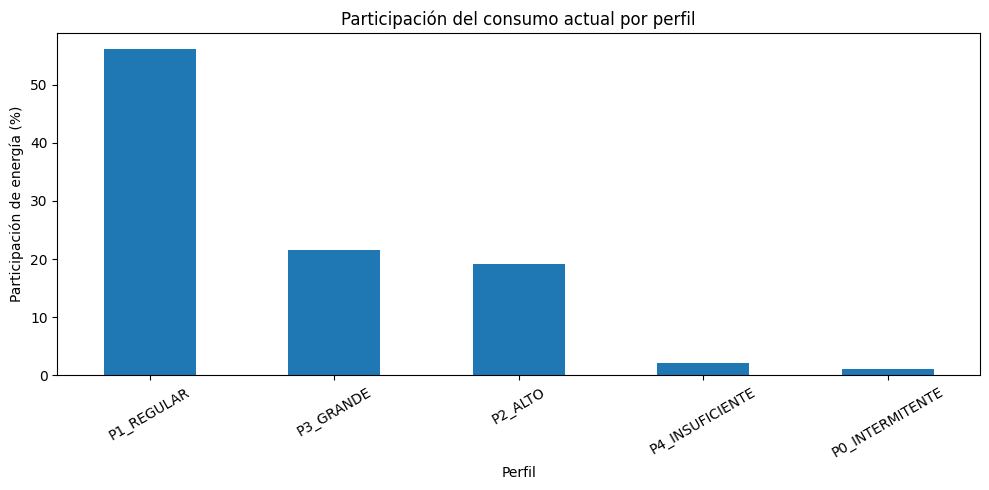

In [34]:
# ============================================================
# 12. GRÁFICA DE COMPOSICIÓN POR PERFIL
# ============================================================

plot_perfiles = (
    resumen_perfiles_final
    .sort_values(
        "participacion_energia_pct",
        ascending=False,
    )
)

ax = plot_perfiles.plot(
    x="perfil",
    y="participacion_energia_pct",
    kind="bar",
    figsize=(10, 5),
    legend=False,
)

ax.set_title(
    "Participación del consumo actual por perfil"
)

ax.set_xlabel(
    "Perfil"
)

ax.set_ylabel(
    "Participación de energía (%)"
)

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# Features de los modelos especializados

Cada modelo recibe únicamente información conocida hasta la fecha de corte:

- consumo actual;
- lags 1–12 y lag 24;
- mismo mes del año anterior;
- mismo mes de hace 2 años;
- medias, medianas y volatilidad;
- ceros recientes;
- crecimiento reciente;
- régimen observado/reconstruido;
- mes objetivo.

`NIU` nunca se utiliza como predictor.

In [35]:
# ============================================================
# 13. CONSTRUIR FEATURES
# ============================================================

FEATURES = [
    "consumo_actual",
    "lag_1",
    "lag_2",
    "lag_3",
    "lag_4",
    "lag_5",
    "lag_6",
    "lag_12",
    "lag_24",
    "media_3m",
    "media_6m",
    "media_12m",
    "mediana_12m",
    "std_3m",
    "std_6m",
    "std_12m",
    "min_6m",
    "max_6m",
    "max_12m",
    "pct_ceros_6m",
    "pct_ceros_12m",
    "variacion_1m",
    "variacion_3m",
    "ratio_actual_media6",
    "mismo_mes_anio_anterior",
    "mismo_mes_2_anios",
    "reconstruido_actual",
    "pct_reconstruido_12m",
    "mes_objetivo",
    "mes_sin",
    "mes_cos",
]


def crear_features(
    fecha_corte,
    horizonte,
    indices,
):
    fecha_corte = periodo_mes(
        fecha_corte
    )

    fecha_objetivo = sumar_meses(
        fecha_corte,
        horizonte,
    )

    actual = valores_mes(
        fecha_corte,
        indices,
    )

    lags = {
        lag: valores_mes(
            sumar_meses(
                fecha_corte,
                -lag,
            ),
            indices,
        )
        for lag in [
            1, 2, 3, 4, 5, 6, 12, 24
        ]
    }

    v3 = ventana_consumo(
        fecha_corte,
        3,
        indices,
    )

    v6 = ventana_consumo(
        fecha_corte,
        6,
        indices,
    )

    v12 = ventana_consumo(
        fecha_corte,
        12,
        indices,
    )

    media6 = media_nan(v6)

    validos6 = np.sum(
        ~np.isnan(v6),
        axis=1,
    )

    validos12 = np.sum(
        ~np.isnan(v12),
        axis=1,
    )

    ceros6 = np.sum(
        np.where(
            np.isnan(v6),
            False,
            v6 == 0,
        ),
        axis=1,
    )

    ceros12 = np.sum(
        np.where(
            np.isnan(v12),
            False,
            v12 == 0,
        ),
        axis=1,
    )

    pct_ceros6 = np.full(
        len(indices),
        np.nan,
        dtype="float32",
    )

    pct_ceros12 = np.full(
        len(indices),
        np.nan,
        dtype="float32",
    )

    mask6 = validos6 > 0
    mask12 = validos12 > 0

    pct_ceros6[mask6] = (
        ceros6[mask6]
        / validos6[mask6]
    )

    pct_ceros12[mask12] = (
        ceros12[mask12]
        / validos12[mask12]
    )

    ratio = np.full(
        len(indices),
        np.nan,
        dtype="float32",
    )

    mask_ratio = (
        np.isfinite(actual)
        & np.isfinite(media6)
        & (media6 != 0)
    )

    ratio[mask_ratio] = (
        actual[mask_ratio]
        / media6[mask_ratio]
    )

    mismo_mes_1a = valores_mes(
        sumar_meses(
            fecha_objetivo,
            -12,
        ),
        indices,
    )

    mismo_mes_2a = valores_mes(
        sumar_meses(
            fecha_objetivo,
            -24,
        ),
        indices,
    )

    reconstruido_actual = (
        valores_regimen_mes(
            fecha_corte,
            indices,
        )
    )

    if matriz_reconstruido is not None:
        vr12 = ventana_regimen(
            fecha_corte,
            12,
            indices,
        )

        pct_reconstruido12 = (
            media_nan(vr12)
        )
    else:
        pct_reconstruido12 = np.full(
            len(indices),
            np.nan,
            dtype="float32",
        )

    mes_obj = fecha_objetivo.month

    X = pd.DataFrame(
        {
            "consumo_actual":
                actual,

            "lag_1":
                lags[1],

            "lag_2":
                lags[2],

            "lag_3":
                lags[3],

            "lag_4":
                lags[4],

            "lag_5":
                lags[5],

            "lag_6":
                lags[6],

            "lag_12":
                lags[12],

            "lag_24":
                lags[24],

            "media_3m":
                media_nan(v3),

            "media_6m":
                media6,

            "media_12m":
                media_nan(v12),

            "mediana_12m":
                mediana_nan(v12),

            "std_3m":
                std_nan(v3),

            "std_6m":
                std_nan(v6),

            "std_12m":
                std_nan(v12),

            "min_6m":
                min_nan(v6),

            "max_6m":
                max_nan(v6),

            "max_12m":
                max_nan(v12),

            "pct_ceros_6m":
                pct_ceros6,

            "pct_ceros_12m":
                pct_ceros12,

            "variacion_1m":
                (
                    actual
                    - lags[1]
                ).astype("float32"),

            "variacion_3m":
                (
                    actual
                    - lags[3]
                ).astype("float32"),

            "ratio_actual_media6":
                ratio,

            "mismo_mes_anio_anterior":
                mismo_mes_1a,

            "mismo_mes_2_anios":
                mismo_mes_2a,

            "reconstruido_actual":
                reconstruido_actual,

            "pct_reconstruido_12m":
                pct_reconstruido12,

            "mes_objetivo":
                np.full(
                    len(indices),
                    mes_obj,
                    dtype="float32",
                ),

            "mes_sin":
                np.full(
                    len(indices),
                    np.sin(
                        2
                        * np.pi
                        * mes_obj
                        / 12
                    ),
                    dtype="float32",
                ),

            "mes_cos":
                np.full(
                    len(indices),
                    np.cos(
                        2
                        * np.pi
                        * mes_obj
                        / 12
                    ),
                    dtype="float32",
                ),
        }
    )

    return X[
        FEATURES
    ], fecha_objetivo

In [36]:
# ============================================================
# 14. MÉTRICAS Y BASELINE
# ============================================================

def metricas_regresion(
    real,
    pred,
):
    real = np.asarray(
        real,
        dtype="float64",
    )

    pred = np.asarray(
        pred,
        dtype="float64",
    )

    mask = (
        np.isfinite(real)
        & np.isfinite(pred)
    )

    real = real[mask]
    pred = pred[mask]

    if len(real) == 0:
        return {
            "n": 0,
            "MAE": np.nan,
            "RMSE": np.nan,
            "WAPE_pct": np.nan,
            "sMAPE_pct": np.nan,
            "R2": np.nan,
            "sesgo_pct": np.nan,
        }

    mae = mean_absolute_error(
        real,
        pred,
    )

    rmse = np.sqrt(
        mean_squared_error(
            real,
            pred,
        )
    )

    suma_real = np.abs(
        real
    ).sum()

    wape = (
        np.abs(
            real - pred
        ).sum()
        / suma_real
        * 100
        if suma_real > 0
        else np.nan
    )

    denom = (
        np.abs(real)
        + np.abs(pred)
    )

    mask_smape = denom > 0

    smape = (
        np.mean(
            2
            * np.abs(
                real[mask_smape]
                - pred[mask_smape]
            )
            / denom[mask_smape]
        )
        * 100
        if mask_smape.any()
        else 0.0
    )

    r2 = (
        r2_score(
            real,
            pred,
        )
        if len(real) > 1
        else np.nan
    )

    sesgo = (
        (
            pred.sum()
            - real.sum()
        )
        / real.sum()
        * 100
        if real.sum() != 0
        else np.nan
    )

    return {
        "n": int(len(real)),
        "MAE": float(mae),
        "RMSE": float(rmse),
        "WAPE_pct": float(wape),
        "sMAPE_pct": float(smape),
        "R2": float(r2),
        "sesgo_pct": float(sesgo),
    }


def baseline_hibrido(
    fecha_corte,
    horizonte,
    indices,
):
    fecha_target = sumar_meses(
        fecha_corte,
        horizonte,
    )

    estacional = valores_mes(
        sumar_meses(
            fecha_target,
            -12,
        ),
        indices,
    )

    actual = valores_mes(
        fecha_corte,
        indices,
    )

    return np.where(
        np.isfinite(estacional),
        estacional,
        actual,
    ).astype("float32")

# Comparación de LightGBM, XGBoost y CatBoost

A partir de este punto los tres algoritmos reciben exactamente el mismo `X_train` y `y_train` para cada combinación de perfil y horizonte.

La competencia se realiza **solo en validación temporal**.

Para cada modelo se calculan dos resultados:

1. **ML puro**
2. **ML + baseline**, optimizando `alpha`

La selección final utiliza el menor `WAPE_blend_validacion_pct`. En caso de empate se usa como desempate el WAPE del ML puro.

In [37]:
# ============================================================
# 15. FÁBRICAS DE MODELOS POR ALGORITMO
# ============================================================

def nuevo_clasificador(
    algoritmo,
):
    if algoritmo == "LightGBM":
        return LGBMClassifier(
            objective="binary",
            n_estimators=350,
            learning_rate=0.05,
            num_leaves=63,
            min_child_samples=100,
            subsample=0.90,
            colsample_bytree=0.90,
            reg_lambda=0.50,
            random_state=SEED,
            n_jobs=-1,
            verbosity=-1,
        )

    if algoritmo == "XGBoost":
        return XGBClassifier(
            objective="binary:logistic",
            n_estimators=350,
            learning_rate=0.05,
            max_depth=8,
            min_child_weight=20,
            subsample=0.90,
            colsample_bytree=0.90,
            reg_lambda=1.0,
            tree_method="hist",
            random_state=SEED,
            n_jobs=-1,
            verbosity=0,
        )

    if algoritmo == "CatBoost":
        return CatBoostClassifier(
            loss_function="Logloss",
            iterations=350,
            learning_rate=0.05,
            depth=8,
            l2_leaf_reg=5.0,
            random_seed=SEED,
            verbose=False,
            allow_writing_files=False,
            thread_count=-1,
        )

    raise ValueError(
        f"Algoritmo no reconocido: {algoritmo}"
    )


def nuevo_regresor_log(
    algoritmo,
):
    if algoritmo == "LightGBM":
        return LGBMRegressor(
            objective="regression",
            n_estimators=500,
            learning_rate=0.04,
            num_leaves=63,
            min_child_samples=100,
            subsample=0.90,
            colsample_bytree=0.90,
            reg_alpha=0.05,
            reg_lambda=0.50,
            random_state=SEED,
            n_jobs=-1,
            verbosity=-1,
        )

    if algoritmo == "XGBoost":
        return XGBRegressor(
            objective="reg:squarederror",
            n_estimators=500,
            learning_rate=0.04,
            max_depth=8,
            min_child_weight=20,
            subsample=0.90,
            colsample_bytree=0.90,
            reg_alpha=0.05,
            reg_lambda=1.0,
            tree_method="hist",
            random_state=SEED,
            n_jobs=-1,
            verbosity=0,
        )

    if algoritmo == "CatBoost":
        return CatBoostRegressor(
            loss_function="RMSE",
            iterations=500,
            learning_rate=0.04,
            depth=8,
            l2_leaf_reg=5.0,
            random_seed=SEED,
            verbose=False,
            allow_writing_files=False,
            thread_count=-1,
        )

    raise ValueError(
        f"Algoritmo no reconocido: {algoritmo}"
    )


def nuevo_regresor_tweedie(
    algoritmo,
    gran_consumidor=False,
):
    iteraciones = (
        650
        if gran_consumidor
        else 550
    )

    if algoritmo == "LightGBM":
        return LGBMRegressor(
            objective="tweedie",
            tweedie_variance_power=1.5,
            n_estimators=iteraciones,
            learning_rate=0.035,
            num_leaves=(
                31
                if gran_consumidor
                else 63
            ),
            min_child_samples=(
                20
                if gran_consumidor
                else 50
            ),
            subsample=0.95,
            colsample_bytree=0.95,
            reg_alpha=0.05,
            reg_lambda=1.0,
            random_state=SEED,
            n_jobs=-1,
            verbosity=-1,
        )

    if algoritmo == "XGBoost":
        return XGBRegressor(
            objective="reg:tweedie",
            tweedie_variance_power=1.5,
            n_estimators=iteraciones,
            learning_rate=0.035,
            max_depth=(
                6
                if gran_consumidor
                else 8
            ),
            min_child_weight=(
                10
                if gran_consumidor
                else 20
            ),
            subsample=0.95,
            colsample_bytree=0.95,
            reg_alpha=0.05,
            reg_lambda=1.0,
            tree_method="hist",
            random_state=SEED,
            n_jobs=-1,
            verbosity=0,
        )

    if algoritmo == "CatBoost":
        return CatBoostRegressor(
            loss_function="Tweedie:variance_power=1.5",
            iterations=iteraciones,
            learning_rate=0.035,
            depth=(
                7
                if gran_consumidor
                else 8
            ),
            l2_leaf_reg=5.0,
            random_seed=SEED,
            verbose=False,
            allow_writing_files=False,
            thread_count=-1,
        )

    raise ValueError(
        f"Algoritmo no reconocido: {algoritmo}"
    )

In [38]:
# ============================================================
# 16. CONSTRUIR TRAIN PARA UN PERFIL Y HORIZONTE
# ============================================================

def construir_train_perfil_h(
    perfil,
    horizonte,
    max_target_train,
    seed,
):
    rng = np.random.default_rng(
        seed
    )

    max_target_train = periodo_mes(
        max_target_train
    )

    ultimo_origen = sumar_meses(
        max_target_train,
        -horizonte,
    )

    origenes = pd.date_range(
        start=PRIMER_ORIGEN_TRAIN,
        end=ultimo_origen,
        freq="MS",
    )

    X_partes = []
    y_partes = []
    auditoria = []

    limite = (
        MAX_MUESTRA_POR_ORIGEN[
            perfil
        ]
    )

    for numero, origen in enumerate(
        origenes,
        start=1,
    ):
        perfiles_origen = calcular_perfiles(
            origen
        )

        idx_perfil = (
            perfiles_origen.loc[
                perfiles_origen[
                    "perfil"
                ].eq(perfil),
                "indice",
            ]
            .to_numpy(
                dtype="int64"
            )
        )

        if len(idx_perfil) == 0:
            continue

        y_all, fecha_target = (
            target_horizonte(
                origen,
                horizonte,
                idx_perfil,
            )
        )

        candidatos = idx_perfil[
            np.isfinite(
                y_all
            )
        ]

        if len(candidatos) == 0:
            continue

        if (
            limite is not None
            and len(candidatos) > limite
        ):
            seleccion = rng.choice(
                candidatos,
                size=limite,
                replace=False,
            )
        else:
            seleccion = candidatos

        y_sel, _ = target_horizonte(
            origen,
            horizonte,
            seleccion,
        )

        X_sel, _ = crear_features(
            origen,
            horizonte,
            seleccion,
        )

        X_partes.append(
            X_sel
        )

        y_partes.append(
            y_sel.astype(
                "float32"
            )
        )

        auditoria.append(
            {
                "perfil":
                    perfil,

                "horizonte":
                    horizonte,

                "origen":
                    origen,

                "target":
                    fecha_target,

                "candidatos":
                    len(candidatos),

                "muestra":
                    len(seleccion),
            }
        )

        if (
            numero == 1
            or numero % 6 == 0
            or numero == len(origenes)
        ):
            print(
                f"{perfil} | h={horizonte} | "
                f"{numero}/{len(origenes)} | "
                f"origen={origen:%Y-%m} | "
                f"muestra={len(seleccion):,}"
            )

        del perfiles_origen
        del X_sel
        gc.collect()

    if not X_partes:
        return (
            pd.DataFrame(
                columns=FEATURES
            ),
            np.array(
                [],
                dtype="float32",
            ),
            pd.DataFrame(),
        )

    X = pd.concat(
        X_partes,
        ignore_index=True,
    )

    y = np.concatenate(
        y_partes
    ).astype("float32")

    auditoria = pd.DataFrame(
        auditoria
    )

    del X_partes
    del y_partes
    gc.collect()

    return X, y, auditoria

In [39]:
# ============================================================
# 17. ENTRENAR / PREDECIR UN ALGORITMO SEGÚN EL PERFIL
# ============================================================

def entrenar_modelo_algoritmo(
    perfil,
    algoritmo,
    X,
    y,
):
    if len(y) == 0:
        return None

    # --------------------------------------------------------
    # P0: hurdle = clasificador + regresor positivo
    # --------------------------------------------------------

    if perfil == "P0_INTERMITENTE":

        y_bin = (
            y > 0
        ).astype("int8")

        bundle = {
            "perfil":
                perfil,

            "algoritmo":
                algoritmo,

            "tipo":
                "hurdle",

            "prob_constante":
                float(
                    y_bin.mean()
                ),

            "classifier":
                None,

            "regressor":
                None,
        }

        if np.unique(
            y_bin
        ).size >= 2:

            clf = nuevo_clasificador(
                algoritmo
            )

            clf.fit(
                X,
                y_bin,
            )

            bundle[
                "classifier"
            ] = clf

        positivos = (
            y > 0
        )

        if positivos.any():

            reg = nuevo_regresor_log(
                algoritmo
            )

            reg.fit(
                X.loc[
                    positivos
                ],
                np.log1p(
                    y[
                        positivos
                    ]
                ),
            )

            bundle[
                "regressor"
            ] = reg

        return bundle

    # --------------------------------------------------------
    # P1: log1p
    # --------------------------------------------------------

    if perfil == "P1_REGULAR":

        reg = nuevo_regresor_log(
            algoritmo
        )

        reg.fit(
            X,
            np.log1p(
                np.maximum(
                    y,
                    0,
                )
            ),
        )

        return {
            "perfil":
                perfil,

            "algoritmo":
                algoritmo,

            "tipo":
                "log",

            "regressor":
                reg,
        }

    # --------------------------------------------------------
    # P2/P3: Tweedie en kWh
    # --------------------------------------------------------

    if perfil in [
        "P2_ALTO",
        "P3_GRANDE",
    ]:

        reg = nuevo_regresor_tweedie(
            algoritmo=algoritmo,
            gran_consumidor=(
                perfil
                == "P3_GRANDE"
            ),
        )

        reg.fit(
            X,
            np.maximum(
                y,
                0,
            ),
        )

        return {
            "perfil":
                perfil,

            "algoritmo":
                algoritmo,

            "tipo":
                "tweedie",

            "regressor":
                reg,
        }

    raise ValueError(
        f"Perfil no reconocido: {perfil}"
    )


def predecir_bundle(
    bundle,
    X,
):
    if bundle is None:
        return np.full(
            len(X),
            np.nan,
            dtype="float32",
        )

    tipo = bundle[
        "tipo"
    ]

    algoritmo = bundle[
        "algoritmo"
    ]

    if tipo == "hurdle":

        if (
            bundle[
                "classifier"
            ]
            is None
        ):
            p_pos = np.full(
                len(X),
                bundle[
                    "prob_constante"
                ],
                dtype="float32",
            )
        else:
            p_pos = (
                bundle[
                    "classifier"
                ]
                .predict_proba(
                    X
                )[:, 1]
                .astype(
                    "float32"
                )
            )

        if (
            bundle[
                "regressor"
            ]
            is None
        ):
            consumo_positivo = np.zeros(
                len(X),
                dtype="float32",
            )
        else:
            consumo_positivo = np.maximum(
                np.expm1(
                    bundle[
                        "regressor"
                    ].predict(
                        X
                    )
                ),
                0,
            ).astype(
                "float32"
            )

        return (
            p_pos
            * consumo_positivo
        ).astype(
            "float32"
        )

    if tipo == "log":

        return np.maximum(
            np.expm1(
                bundle[
                    "regressor"
                ].predict(
                    X
                )
            ),
            0,
        ).astype(
            "float32"
        )

    if tipo == "tweedie":

        if algoritmo == "CatBoost":

            pred = (
                bundle[
                    "regressor"
                ]
                .predict(
                    X,
                    prediction_type="Exponent",
                )
            )

        else:

            pred = (
                bundle[
                    "regressor"
                ]
                .predict(
                    X
                )
            )

        return np.maximum(
            pred,
            0,
        ).astype(
            "float32"
        )

    raise ValueError(
        f"Tipo de bundle no reconocido: {tipo}"
    )

In [40]:
# ============================================================
# 18. COMPONENTES DE MÉTRICAS ACUMULABLES
# ============================================================

def componentes_vacios():
    return {
        "n":
            0,

        "abs_error_sum":
            0.0,

        "sq_error_sum":
            0.0,

        "abs_real_sum":
            0.0,

        "real_sum":
            0.0,

        "real_sq_sum":
            0.0,

        "pred_sum":
            0.0,

        "smape_sum":
            0.0,

        "smape_n":
            0,
    }


def actualizar_componentes(
    comp,
    real,
    pred,
):
    real = np.asarray(
        real,
        dtype="float64",
    )

    pred = np.asarray(
        pred,
        dtype="float64",
    )

    mask = (
        np.isfinite(real)
        & np.isfinite(pred)
    )

    real = real[mask]
    pred = pred[mask]

    if len(real) == 0:
        return comp

    error = (
        pred
        - real
    )

    comp[
        "n"
    ] += len(
        real
    )

    comp[
        "abs_error_sum"
    ] += float(
        np.abs(
            error
        ).sum()
    )

    comp[
        "sq_error_sum"
    ] += float(
        np.square(
            error
        ).sum()
    )

    comp[
        "abs_real_sum"
    ] += float(
        np.abs(
            real
        ).sum()
    )

    comp[
        "real_sum"
    ] += float(
        real.sum()
    )

    comp[
        "real_sq_sum"
    ] += float(
        np.square(
            real
        ).sum()
    )

    comp[
        "pred_sum"
    ] += float(
        pred.sum()
    )

    denom = (
        np.abs(
            real
        )
        + np.abs(
            pred
        )
    )

    mask_smape = (
        denom > 0
    )

    if mask_smape.any():

        comp[
            "smape_sum"
        ] += float(
            (
                2
                * np.abs(
                    real[
                        mask_smape
                    ]
                    - pred[
                        mask_smape
                    ]
                )
                / denom[
                    mask_smape
                ]
            ).sum()
        )

        comp[
            "smape_n"
        ] += int(
            mask_smape.sum()
        )

    return comp


def metricas_componentes(
    comp,
):
    n = comp[
        "n"
    ]

    if n == 0:
        return {
            "n": 0,
            "MAE": np.nan,
            "RMSE": np.nan,
            "WAPE_pct": np.nan,
            "sMAPE_pct": np.nan,
            "R2": np.nan,
            "sesgo_pct": np.nan,
        }

    mae = (
        comp[
            "abs_error_sum"
        ]
        / n
    )

    rmse = np.sqrt(
        comp[
            "sq_error_sum"
        ]
        / n
    )

    wape = (
        comp[
            "abs_error_sum"
        ]
        / comp[
            "abs_real_sum"
        ]
        * 100
        if comp[
            "abs_real_sum"
        ] > 0
        else np.nan
    )

    smape = (
        comp[
            "smape_sum"
        ]
        / comp[
            "smape_n"
        ]
        * 100
        if comp[
            "smape_n"
        ] > 0
        else np.nan
    )

    media_real = (
        comp[
            "real_sum"
        ]
        / n
    )

    sst = (
        comp[
            "real_sq_sum"
        ]
        - n
        * media_real**2
    )

    r2 = (
        1
        - (
            comp[
                "sq_error_sum"
            ]
            / sst
        )
        if sst > 0
        else np.nan
    )

    sesgo = (
        (
            comp[
                "pred_sum"
            ]
            - comp[
                "real_sum"
            ]
        )
        / comp[
            "real_sum"
        ]
        * 100
        if comp[
            "real_sum"
        ] != 0
        else np.nan
    )

    return {
        "n":
            int(
                n
            ),

        "MAE":
            float(
                mae
            ),

        "RMSE":
            float(
                rmse
            ),

        "WAPE_pct":
            float(
                wape
            ),

        "sMAPE_pct":
            float(
                smape
            ),

        "R2":
            float(
                r2
            ),

        "sesgo_pct":
            float(
                sesgo
            ),
    }

In [41]:
# ============================================================
# 19. OBTENER DATASET DE VALIDACIÓN PARA UN GRUPO
# ============================================================

def obtener_validacion_grupo(
    perfil,
    horizonte,
    fecha_corte,
):
    perfiles_corte = calcular_perfiles(
        fecha_corte
    )

    indices = (
        perfiles_corte.loc[
            perfiles_corte[
                "perfil"
            ].eq(
                perfil
            ),
            "indice",
        ]
        .to_numpy(
            dtype="int64"
        )
    )

    if len(indices) == 0:
        return None

    y_real, fecha_target = (
        target_horizonte(
            fecha_corte,
            horizonte,
            indices,
        )
    )

    mask = np.isfinite(
        y_real
    )

    indices = indices[
        mask
    ]

    y_real = y_real[
        mask
    ].astype(
        "float32"
    )

    if len(indices) == 0:
        return None

    X, _ = crear_features(
        fecha_corte,
        horizonte,
        indices,
    )

    baseline = baseline_hibrido(
        fecha_corte,
        horizonte,
        indices,
    )

    return {
        "indices":
            indices,

        "X":
            X,

        "real":
            y_real,

        "baseline":
            baseline,

        "fecha_target":
            fecha_target,
    }

## Fábricas de modelos parametrizadas (idénticas al notebook de optimización)

In [42]:
# ============================================================
# 22. OPTUNA (SOLO PARA FixedTrial) Y FÁBRICAS PARAMETRIZADAS
# ============================================================
# No se corre ninguna búsqueda aquí. FixedTrial permite reutilizar
# las mismas fábricas del notebook de optimización pasando un
# diccionario de hiperparámetros ya decididos, en vez de un trial
# que sigue explorando.
# ============================================================

import json as _json

try:
    import optuna
    from optuna.trial import FixedTrial
except ImportError as e:
    raise ImportError(
        "Falta Optuna. Ejecuta: %pip install -U optuna"
    ) from e

optuna.logging.set_verbosity(optuna.logging.WARNING)


def sugerir_hparams_arbol(trial, prefijo, algoritmo, es_tweedie=False):

    def p(nombre):
        return f"{prefijo}_{nombre}"

    if algoritmo == "LightGBM":
        params = {
            "n_estimators": trial.suggest_int(p("n_estimators"), 200, 1000, step=50),
            "learning_rate": trial.suggest_float(p("learning_rate"), 0.01, 0.15, log=True),
            "num_leaves": trial.suggest_int(p("num_leaves"), 15, 255, log=True),
            "min_child_samples": trial.suggest_int(p("min_child_samples"), 10, 200, log=True),
            "subsample": trial.suggest_float(p("subsample"), 0.6, 1.0),
            "colsample_bytree": trial.suggest_float(p("colsample_bytree"), 0.6, 1.0),
            "reg_alpha": trial.suggest_float(p("reg_alpha"), 1e-3, 5.0, log=True),
            "reg_lambda": trial.suggest_float(p("reg_lambda"), 1e-3, 5.0, log=True),
        }
        if es_tweedie:
            params["tweedie_variance_power"] = trial.suggest_float(p("tweedie_variance_power"), 1.1, 1.9)
        return params

    if algoritmo == "XGBoost":
        params = {
            "n_estimators": trial.suggest_int(p("n_estimators"), 200, 1000, step=50),
            "learning_rate": trial.suggest_float(p("learning_rate"), 0.01, 0.15, log=True),
            "max_depth": trial.suggest_int(p("max_depth"), 3, 12),
            "min_child_weight": trial.suggest_float(p("min_child_weight"), 1.0, 50.0, log=True),
            "subsample": trial.suggest_float(p("subsample"), 0.6, 1.0),
            "colsample_bytree": trial.suggest_float(p("colsample_bytree"), 0.6, 1.0),
            "reg_alpha": trial.suggest_float(p("reg_alpha"), 1e-3, 5.0, log=True),
            "reg_lambda": trial.suggest_float(p("reg_lambda"), 1e-3, 5.0, log=True),
        }
        if es_tweedie:
            params["tweedie_variance_power"] = trial.suggest_float(p("tweedie_variance_power"), 1.1, 1.9)
        return params

    if algoritmo == "CatBoost":
        params = {
            "iterations": trial.suggest_int(p("iterations"), 200, 1000, step=50),
            "learning_rate": trial.suggest_float(p("learning_rate"), 0.01, 0.15, log=True),
            "depth": trial.suggest_int(p("depth"), 4, 10),
            "l2_leaf_reg": trial.suggest_float(p("l2_leaf_reg"), 1.0, 10.0, log=True),
        }
        if es_tweedie:
            params["tweedie_variance_power"] = trial.suggest_float(p("tweedie_variance_power"), 1.1, 1.9)
        return params

    raise ValueError(f"Algoritmo no reconocido: {algoritmo}")


def construir_clasificador_optuna(trial, algoritmo, prefijo="clf"):
    hp = sugerir_hparams_arbol(trial, prefijo, algoritmo)

    if algoritmo == "LightGBM":
        return LGBMClassifier(
            objective="binary", random_state=SEED, n_jobs=-1, verbosity=-1, **hp,
        )
    if algoritmo == "XGBoost":
        return XGBClassifier(
            objective="binary:logistic", tree_method="hist",
            random_state=SEED, n_jobs=-1, verbosity=0, **hp,
        )
    if algoritmo == "CatBoost":
        return CatBoostClassifier(
            loss_function="Logloss", random_seed=SEED, verbose=False,
            allow_writing_files=False, thread_count=-1, **hp,
        )
    raise ValueError(f"Algoritmo no reconocido: {algoritmo}")


def construir_regresor_log_optuna(trial, algoritmo, prefijo="reg"):
    hp = sugerir_hparams_arbol(trial, prefijo, algoritmo)

    if algoritmo == "LightGBM":
        return LGBMRegressor(
            objective="regression", random_state=SEED, n_jobs=-1, verbosity=-1, **hp,
        )
    if algoritmo == "XGBoost":
        return XGBRegressor(
            objective="reg:squarederror", tree_method="hist",
            random_state=SEED, n_jobs=-1, verbosity=0, **hp,
        )
    if algoritmo == "CatBoost":
        return CatBoostRegressor(
            loss_function="RMSE", random_seed=SEED, verbose=False,
            allow_writing_files=False, thread_count=-1, **hp,
        )
    raise ValueError(f"Algoritmo no reconocido: {algoritmo}")


def construir_regresor_tweedie_optuna(trial, algoritmo, prefijo="reg"):
    hp = sugerir_hparams_arbol(trial, prefijo, algoritmo, es_tweedie=True)
    potencia = hp.pop("tweedie_variance_power")

    if algoritmo == "LightGBM":
        return LGBMRegressor(
            objective="tweedie", tweedie_variance_power=potencia,
            random_state=SEED, n_jobs=-1, verbosity=-1, **hp,
        )
    if algoritmo == "XGBoost":
        return XGBRegressor(
            objective="reg:tweedie", tweedie_variance_power=potencia,
            tree_method="hist", random_state=SEED, n_jobs=-1, verbosity=0, **hp,
        )
    if algoritmo == "CatBoost":
        return CatBoostRegressor(
            loss_function=f"Tweedie:variance_power={potencia:.3f}",
            random_seed=SEED, verbose=False,
            allow_writing_files=False, thread_count=-1, **hp,
        )
    raise ValueError(f"Algoritmo no reconocido: {algoritmo}")


def entrenar_modelo_algoritmo_optuna(perfil, algoritmo, X, y, trial):
    if len(y) == 0:
        return None

    if perfil == "P0_INTERMITENTE":

        y_bin = (y > 0).astype("int8")

        bundle = {
            "perfil": perfil,
            "algoritmo": algoritmo,
            "tipo": "hurdle",
            "prob_constante": float(y_bin.mean()),
            "classifier": None,
            "regressor": None,
        }

        if np.unique(y_bin).size >= 2:
            clf = construir_clasificador_optuna(trial, algoritmo, prefijo="clf")
            clf.fit(X, y_bin)
            bundle["classifier"] = clf

        positivos = y > 0

        if positivos.any():
            reg = construir_regresor_log_optuna(trial, algoritmo, prefijo="reg")
            reg.fit(X.loc[positivos], np.log1p(y[positivos]))
            bundle["regressor"] = reg

        return bundle

    if perfil == "P1_REGULAR":
        reg = construir_regresor_log_optuna(trial, algoritmo, prefijo="reg")
        reg.fit(X, np.log1p(np.maximum(y, 0)))

        return {
            "perfil": perfil, "algoritmo": algoritmo,
            "tipo": "log", "regressor": reg,
        }

    if perfil in ["P2_ALTO", "P3_GRANDE"]:
        reg = construir_regresor_tweedie_optuna(trial, algoritmo, prefijo="reg")
        reg.fit(X, np.maximum(y, 0))

        return {
            "perfil": perfil, "algoritmo": algoritmo,
            "tipo": "tweedie", "regressor": reg,
        }

    raise ValueError(f"Perfil no reconocido: {perfil}")


## Cargar hiperparámetros y selección optimizada

In [43]:
# ============================================================
# 23. CARGAR HIPERPARÁMETROS Y SELECCIÓN OPTIMIZADA
# ============================================================

RUTA_SELECCION_OPTIMIZADA = SALIDA_DIR / "seleccion_modelo_por_perfil_horizonte_optimizada.csv"
RUTA_HIPERPARAMETROS = SALIDA_DIR / "hiperparametros_optimos_por_grupo.json"

for ruta in [RUTA_SELECCION_OPTIMIZADA, RUTA_HIPERPARAMETROS]:
    if not ruta.exists():
        raise FileNotFoundError(
            f"No existe:\n{ruta}\n"
            "Corre primero Optimizacion_hiperparametros_modelos_ganadores.ipynb."
        )

seleccion_modelos_optimizada = pd.read_csv(RUTA_SELECCION_OPTIMIZADA)

with open(RUTA_HIPERPARAMETROS, "r", encoding="utf-8") as f:
    mejores_hparams = _json.load(f)

mapa_seleccion_optimizado = {
    (fila.perfil, int(fila.horizonte)): {
        "modelo": fila.algoritmo,
        "alpha_ml": float(fila.alpha_ml_optimizado),
        "alpha_baseline": float(1 - fila.alpha_ml_optimizado),
        "clave_hparams": f"{fila.perfil}_h{int(fila.horizonte)}_{fila.algoritmo}",
    }
    for fila in seleccion_modelos_optimizada.itertuples(index=False)
}

display(
    seleccion_modelos_optimizada
    .sort_values(["perfil", "horizonte"])
)


,perfil,horizonte,algoritmo,WAPE_blend_original_pct,WAPE_blend_optimizado_pct,mejora_pct_puntos,alpha_ml_optimizado,n_trials
0,P0_INTERMITENTE,1,LightGBM,48.182144,48.227067,-0.044923,1.00,25
1,P0_INTERMITENTE,2,LightGBM,53.944709,53.576689,0.368020,1.00,25
2,P0_INTERMITENTE,3,LightGBM,71.366157,71.364273,0.001884,1.00,25
3,P0_INTERMITENTE,4,LightGBM,78.898085,78.756704,0.141381,1.00,25
4,P0_INTERMITENTE,5,LightGBM,79.813781,79.497394,0.316387,1.00,25
5,P0_INTERMITENTE,6,LightGBM,81.969911,81.615299,0.354611,1.00,25
6,P1_REGULAR,1,XGBoost,15.603315,15.536809,0.066506,1.00,25
7,P1_REGULAR,2,XGBoost,17.500512,17.453515,0.046997,1.00,25
8,P1_REGULAR,3,XGBoost,21.847135,21.723108,0.124027,1.00,25
9,P1_REGULAR,4,LightGBM,23.939647,23.876524,0.063123,0.95,25


# Etapa 1 — Backtest del sistema optimizado (2025-07-01)

In [44]:
# ============================================================
# 24. REENTRENAR GANADORES OPTIMIZADOS PARA BACKTEST
# ============================================================
# Mismo criterio que la celda "29. REENTRENAR GANADORES PARA BACKTEST"
# del notebook de comparación: se entrena con todo lo conocido hasta
# justo antes de CORTE_BACKTEST_FINAL. La única diferencia es que aquí
# se usan los hiperparámetros optimizados en vez de los valores fijos.
# ============================================================

modelos_backtest_optimizado = {}

for perfil in PERFILES_MODELADOS:

    for h in HORIZONTES:

        config = mapa_seleccion_optimizado[(perfil, h)]
        algoritmo = config["modelo"]
        clave = config["clave_hparams"]

        print("\n" + "=" * 75)
        print(f"BACKTEST OPTIMIZADO TRAIN | {perfil} | h={h} | {algoritmo}")
        print("=" * 75)

        inicio = time.time()

        X_train, y_train, _ = construir_train_perfil_h(
            perfil=perfil,
            horizonte=h,
            max_target_train=CORTE_BACKTEST_FINAL,
            seed=SEED + 200 + h,
        )

        trial_fijo = FixedTrial(mejores_hparams[clave])

        bundle = entrenar_modelo_algoritmo_optuna(
            perfil, algoritmo, X_train, y_train, trial_fijo,
        )

        modelos_backtest_optimizado[(perfil, h)] = bundle

        print(
            "Train:", X_train.shape,
            "| tiempo:", f"{(time.time() - inicio) / 60:.2f} min"
        )

        del X_train, y_train
        gc.collect()



BACKTEST OPTIMIZADO TRAIN | P0_INTERMITENTE | h=1 | LightGBM
P0_INTERMITENTE | h=1 | 1/30 | origen=2023-01 | muestra=40,000
P0_INTERMITENTE | h=1 | 6/30 | origen=2023-06 | muestra=40,000
P0_INTERMITENTE | h=1 | 12/30 | origen=2023-12 | muestra=40,000
P0_INTERMITENTE | h=1 | 18/30 | origen=2024-06 | muestra=40,000
P0_INTERMITENTE | h=1 | 24/30 | origen=2024-12 | muestra=40,000
P0_INTERMITENTE | h=1 | 30/30 | origen=2025-06 | muestra=40,000
Train: (1200000, 31) | tiempo: 0.98 min

BACKTEST OPTIMIZADO TRAIN | P0_INTERMITENTE | h=2 | LightGBM
P0_INTERMITENTE | h=2 | 1/29 | origen=2023-01 | muestra=40,000
P0_INTERMITENTE | h=2 | 6/29 | origen=2023-06 | muestra=40,000
P0_INTERMITENTE | h=2 | 12/29 | origen=2023-12 | muestra=40,000
P0_INTERMITENTE | h=2 | 18/29 | origen=2024-06 | muestra=40,000
P0_INTERMITENTE | h=2 | 24/29 | origen=2024-12 | muestra=40,000
P0_INTERMITENTE | h=2 | 29/29 | origen=2025-05 | muestra=40,000
Train: (1160000, 31) | tiempo: 0.98 min

BACKTEST OPTIMIZADO TRAIN | P0_

In [45]:
# ============================================================
# 25. GENERAR BACKTEST DEL SISTEMA OPTIMIZADO
# ============================================================
# Idéntico a la celda "30. GENERAR BACKTEST DEL SISTEMA GANADOR" del
# notebook de comparación, usando los bundles y el alpha optimizados.
# P4_INSUFICIENTE sigue sin modelarse: se queda con el baseline.
# ============================================================

perfiles_backtest = calcular_perfiles(CORTE_BACKTEST_FINAL)

partes_backtest_opt = []

for h in HORIZONTES:

    fecha_target = sumar_meses(CORTE_BACKTEST_FINAL, h)

    for perfil in PERFILES:

        indices = (
            perfiles_backtest.loc[
                perfiles_backtest["perfil"].eq(perfil), "indice",
            ]
            .to_numpy(dtype="int64")
        )

        if len(indices) == 0:
            continue

        y_real, _ = target_horizonte(CORTE_BACKTEST_FINAL, h, indices)

        mask = np.isfinite(y_real)
        indices = indices[mask]
        y_real = y_real[mask].astype("float32")

        if len(indices) == 0:
            continue

        baseline = baseline_hibrido(CORTE_BACKTEST_FINAL, h, indices)

        if perfil == "P4_INSUFICIENTE":
            algoritmo = "Baseline"
            alpha_ml = 0.0
            pred_ml = baseline.copy()
            pred_final = baseline.copy()

        else:
            config = mapa_seleccion_optimizado[(perfil, h)]
            algoritmo = config["modelo"]
            alpha_ml = config["alpha_ml"]

            X, _ = crear_features(CORTE_BACKTEST_FINAL, h, indices)

            pred_ml = predecir_bundle(
                modelos_backtest_optimizado[(perfil, h)], X,
            )

            pred_final = alpha_ml * pred_ml + (1 - alpha_ml) * baseline
            pred_final = np.maximum(pred_final, 0).astype("float32")

            del X

        regimen_actual = valores_regimen_mes(CORTE_BACKTEST_FINAL, indices)

        regimen = np.where(
            regimen_actual == 1, "reconstruido",
            np.where(regimen_actual == 0, "observado", "sin_dato"),
        )

        temp = pd.DataFrame({
            "NIU": nius[indices],
            "fecha_corte": CORTE_BACKTEST_FINAL,
            "horizonte": h,
            "fecha_target": fecha_target,
            "perfil": perfil,
            "regimen_actual": regimen,
            "modelo_ganador": algoritmo,
            "alpha_ml": alpha_ml,
            "real_kwh": y_real,
            "pred_ml_kwh": pred_ml,
            "baseline_kwh": baseline,
            "pred_final_kwh": pred_final,
        })

        partes_backtest_opt.append(temp)
        del temp
        gc.collect()

backtest_optimizado = pd.concat(partes_backtest_opt, ignore_index=True)

print("Filas backtest optimizado:", f"{len(backtest_optimizado):,}")
display(backtest_optimizado.head(20))


Filas backtest optimizado: 3,443,328


,NIU,fecha_corte,horizonte,fecha_target,perfil,regimen_actual,modelo_ganador,alpha_ml,real_kwh,pred_ml_kwh,baseline_kwh,pred_final_kwh
0,100001726,2025-07-01,1,2025-08-01,P0_INTERMITENTE,reconstruido,LightGBM,1.0,0.000000,0.110962,0.000000,0.110962
1,100005854,2025-07-01,1,2025-08-01,P0_INTERMITENTE,reconstruido,LightGBM,1.0,7.000000,6.056829,6.402174,6.056829
2,100008205,2025-07-01,1,2025-08-01,P0_INTERMITENTE,reconstruido,LightGBM,1.0,0.336957,0.388765,0.336957,0.388765
3,100010818,2025-07-01,1,2025-08-01,P0_INTERMITENTE,reconstruido,LightGBM,1.0,0.000000,0.008950,0.000000,0.008950
4,100012482,2025-07-01,1,2025-08-01,P0_INTERMITENTE,reconstruido,LightGBM,1.0,1.684783,2.902019,4.043478,2.902019
5,1000127971,2025-07-01,1,2025-08-01,P0_INTERMITENTE,reconstruido,LightGBM,1.0,0.000000,0.040156,0.000000,0.040156
6,100013269,2025-07-01,1,2025-08-01,P0_INTERMITENTE,reconstruido,LightGBM,1.0,0.000000,0.044282,10.445652,0.044282
7,100016500,2025-07-01,1,2025-08-01,P0_INTERMITENTE,reconstruido,LightGBM,1.0,5.701149,5.687432,26.956522,5.687432
8,1000201208,2025-07-01,1,2025-08-01,P0_INTERMITENTE,observado,LightGBM,1.0,0.000000,0.551878,0.000000,0.551878
9,1000211177,2025-07-01,1,2025-08-01,P0_INTERMITENTE,reconstruido,LightGBM,1.0,0.000000,0.077322,11.094737,0.077322


In [46]:
# ============================================================
# 26. MÉTRICAS DEL BACKTEST OPTIMIZADO (POR PERFIL/HORIZONTE, GLOBALES, RÉGIMEN)
# ============================================================

RUTA_METRICAS_PERFIL_OPT = SALIDA_DIR / "metricas_sistema_por_perfil_horizonte_optimizado.csv"
RUTA_METRICAS_BACKTEST_OPT = SALIDA_DIR / "metricas_sistema_ganador_backtest_optimizado.csv"
RUTA_METRICAS_REGIMEN_OPT = SALIDA_DIR / "metricas_sistema_por_regimen_horizonte_optimizado.csv"
RUTA_REAL_VS_PRED_OPT = SALIDA_DIR / "real_vs_pronosticado_sistema_optimizado_backtest.parquet"

# --- Por perfil / horizonte ---
filas_perfil_opt = []

for (perfil, h), g in backtest_optimizado.groupby(["perfil", "horizonte"]):
    met_final = metricas_regresion(g["real_kwh"], g["pred_final_kwh"])
    met_ml = metricas_regresion(g["real_kwh"], g["pred_ml_kwh"])
    met_base = metricas_regresion(g["real_kwh"], g["baseline_kwh"])

    filas_perfil_opt.append({
        "perfil": perfil,
        "horizonte": h,
        "modelo_ganador": g["modelo_ganador"].mode().iloc[0],
        "alpha_ml": g["alpha_ml"].iloc[0],
        "n": met_final["n"],
        "WAPE_final_pct": met_final["WAPE_pct"],
        "WAPE_ML_pct": met_ml["WAPE_pct"],
        "WAPE_baseline_pct": met_base["WAPE_pct"],
        "MAE_final": met_final["MAE"],
        "RMSE_final": met_final["RMSE"],
        "R2_final": met_final["R2"],
        "sesgo_final_pct": met_final["sesgo_pct"],
    })

metricas_perfil_backtest_optimizado = pd.DataFrame(filas_perfil_opt)

display(metricas_perfil_backtest_optimizado.sort_values(["horizonte", "perfil"]))

metricas_perfil_backtest_optimizado.to_csv(
    RUTA_METRICAS_PERFIL_OPT, index=False, encoding="utf-8-sig",
)

# --- Globales por horizonte ---
filas_global_opt = []

for h, g in backtest_optimizado.groupby("horizonte"):
    final = metricas_regresion(g["real_kwh"], g["pred_final_kwh"])
    ml = metricas_regresion(g["real_kwh"], g["pred_ml_kwh"])
    baseline = metricas_regresion(g["real_kwh"], g["baseline_kwh"])

    filas_global_opt.append({
        "horizonte": h,
        "n": final["n"],
        "WAPE_final_pct": final["WAPE_pct"],
        "WAPE_ML_ganadores_pct": ml["WAPE_pct"],
        "WAPE_baseline_pct": baseline["WAPE_pct"],
        "MAE_final": final["MAE"],
        "RMSE_final": final["RMSE"],
        "R2_final": final["R2"],
        "sesgo_final_pct": final["sesgo_pct"],
    })

metricas_globales_backtest_optimizado = pd.DataFrame(filas_global_opt)

display(metricas_globales_backtest_optimizado)

metricas_globales_backtest_optimizado.to_csv(
    RUTA_METRICAS_BACKTEST_OPT, index=False, encoding="utf-8-sig",
)

# --- Por régimen observado/reconstruido ---
filas_regimen_opt = []

for (regimen, h), g in backtest_optimizado.groupby(["regimen_actual", "horizonte"]):
    met = metricas_regresion(g["real_kwh"], g["pred_final_kwh"])
    filas_regimen_opt.append({"regimen": regimen, "horizonte": h, **met})

metricas_regimen_optimizado = pd.DataFrame(filas_regimen_opt)

display(metricas_regimen_optimizado.sort_values(["regimen", "horizonte"]))

metricas_regimen_optimizado.to_csv(
    RUTA_METRICAS_REGIMEN_OPT, index=False, encoding="utf-8-sig",
)

# --- Real vs pronosticado cliente a cliente ---
backtest_optimizado["error_kwh"] = (
    backtest_optimizado["pred_final_kwh"] - backtest_optimizado["real_kwh"]
)
backtest_optimizado["error_abs_kwh"] = np.abs(backtest_optimizado["error_kwh"])
backtest_optimizado["error_pct"] = np.where(
    backtest_optimizado["real_kwh"] > 0,
    backtest_optimizado["error_kwh"] / backtest_optimizado["real_kwh"] * 100,
    np.nan,
)

backtest_optimizado[[
    "NIU", "fecha_corte", "horizonte", "fecha_target", "perfil",
    "regimen_actual", "modelo_ganador", "alpha_ml",
    "real_kwh", "pred_ml_kwh", "baseline_kwh", "pred_final_kwh",
    "error_kwh", "error_abs_kwh", "error_pct",
]].to_parquet(RUTA_REAL_VS_PRED_OPT, index=False, engine="pyarrow")

print("\nGuardado:", RUTA_METRICAS_PERFIL_OPT)
print("Guardado:", RUTA_METRICAS_BACKTEST_OPT)
print("Guardado:", RUTA_METRICAS_REGIMEN_OPT)
print("Guardado:", RUTA_REAL_VS_PRED_OPT)


,perfil,horizonte,modelo_ganador,alpha_ml,n,WAPE_final_pct,WAPE_ML_pct,WAPE_baseline_pct,MAE_final,RMSE_final,R2_final,sesgo_final_pct
0,P0_INTERMITENTE,1,LightGBM,1.00,109399,44.672315,44.672315,151.490791,3.876244,72.659001,0.235707,-22.600139
6,P1_REGULAR,1,XGBoost,1.00,443719,14.457601,14.457688,33.630997,12.920467,66.709614,0.575855,-3.658502
12,P2_ALTO,1,LightGBM,1.00,10324,15.115366,15.115366,30.263754,181.834783,917.213095,0.556722,-0.043041
18,P3_GRANDE,1,LightGBM,1.00,825,14.363820,14.363820,25.436260,2829.488210,8469.440157,0.972073,0.905707
24,P4_INSUFICIENTE,1,Baseline,0.00,5420,76.982338,76.982338,76.982338,86.607655,975.901224,-0.105072,15.935659
1,P0_INTERMITENTE,2,LightGBM,1.00,109706,55.098866,55.118742,136.460045,5.191203,97.757843,0.120086,-31.728893
7,P1_REGULAR,2,XGBoost,1.00,443817,18.637088,18.637088,33.290950,16.780307,52.493658,0.678245,-10.052800
13,P2_ALTO,2,XGBoost,1.00,10326,18.996366,18.996366,32.002948,235.700240,1511.487475,0.282807,-7.745706
19,P3_GRANDE,2,LightGBM,0.90,824,17.740437,17.731522,27.654056,3522.231246,14834.829880,0.914628,-2.621077
25,P4_INSUFICIENTE,2,Baseline,0.00,5419,154.099127,154.099127,154.099127,167.962209,6170.079904,-56.124147,96.742535


,horizonte,n,WAPE_final_pct,WAPE_ML_ganadores_pct,WAPE_baseline_pct,MAE_final,RMSE_final,R2_final,sesgo_final_pct
0,1,569687,15.508657,15.508706,33.106102,19.024688,364.232943,0.969511,-2.040904
1,2,570092,20.158250,20.156479,34.269953,25.019187,851.660472,0.834679,-7.341873
2,3,570309,24.561821,24.567192,36.527307,28.290558,559.558383,0.931110,-0.879874
3,4,570025,24.423080,24.370654,33.014224,29.503559,550.376879,0.924480,-7.668230
4,5,570034,25.907066,25.761763,34.026305,31.104940,529.859434,0.929636,-6.567876
5,6,568528,37.164441,37.292346,44.211108,40.544902,928.097429,0.732967,5.269859


,regimen,horizonte,n,MAE,RMSE,WAPE_pct,sMAPE_pct,R2,sesgo_pct
0,observado,1,355063,27.508780,460.048814,16.634351,34.010479,0.969616,-1.952013
1,observado,2,354960,36.781733,1078.272941,21.757670,39.317860,0.834639,-8.384708
2,observado,3,355070,34.272648,702.843799,21.522903,39.324697,0.932204,-3.556852
3,observado,4,354842,38.470359,690.354875,23.752593,41.810073,0.925774,-7.078131
4,observado,5,354843,40.622740,663.901411,25.428635,42.648036,0.931011,-5.530295
5,observado,6,355034,47.230613,1172.564532,29.225632,46.047353,0.733281,-4.117984
6,reconstruido,1,214561,4.941407,41.849819,9.496489,37.639314,0.902836,-2.590538
7,reconstruido,2,214743,5.410532,50.068127,10.817778,38.408172,0.847804,-1.876184
8,reconstruido,3,214825,18.098034,77.343233,42.590388,67.491181,0.576440,15.160074
9,reconstruido,4,214776,14.675177,128.574910,27.703130,58.975487,0.446486,-10.691493



Guardado: C:\Users\Home\Documents\Datos Ebsa\Serie_tiempo_consumo\modelacion_consumo_segmentada_comparativa\metricas_sistema_por_perfil_horizonte_optimizado.csv
Guardado: C:\Users\Home\Documents\Datos Ebsa\Serie_tiempo_consumo\modelacion_consumo_segmentada_comparativa\metricas_sistema_ganador_backtest_optimizado.csv
Guardado: C:\Users\Home\Documents\Datos Ebsa\Serie_tiempo_consumo\modelacion_consumo_segmentada_comparativa\metricas_sistema_por_regimen_horizonte_optimizado.csv
Guardado: C:\Users\Home\Documents\Datos Ebsa\Serie_tiempo_consumo\modelacion_consumo_segmentada_comparativa\real_vs_pronosticado_sistema_optimizado_backtest.parquet


## Comparación directa: sistema original vs sistema optimizado (backtest)

COMPARACIÓN POR PERFIL x HORIZONTE (backtest 2025-07-01)


,perfil,horizonte,WAPE_original_pct,WAPE_optimizado_pct,mejora_pct_puntos
0,P0_INTERMITENTE,1,44.818655,44.672315,0.146340
1,P0_INTERMITENTE,2,54.867850,55.098866,-0.231016
2,P0_INTERMITENTE,3,73.742589,73.369917,0.372672
3,P0_INTERMITENTE,4,77.365948,77.691094,-0.325145
4,P0_INTERMITENTE,5,80.621378,80.469855,0.151523
5,P0_INTERMITENTE,6,91.200925,91.077447,0.123479
6,P1_REGULAR,1,14.357467,14.457601,-0.100134
7,P1_REGULAR,2,18.786014,18.637088,0.148926
8,P1_REGULAR,3,25.539209,25.599010,-0.059801
9,P1_REGULAR,4,24.025067,24.169258,-0.144191



COMPARACIÓN GLOBAL POR HORIZONTE (backtest 2025-07-01)


,horizonte,WAPE_original_pct,WAPE_optimizado_pct,mejora_pct_puntos
0,1,15.447941,15.508657,-0.060716
1,2,20.250673,20.158250,0.092423
2,3,24.570577,24.561821,0.008756
3,4,24.273246,24.423080,-0.149834
4,5,26.088936,25.907066,0.181870
5,6,37.080573,37.164441,-0.083868


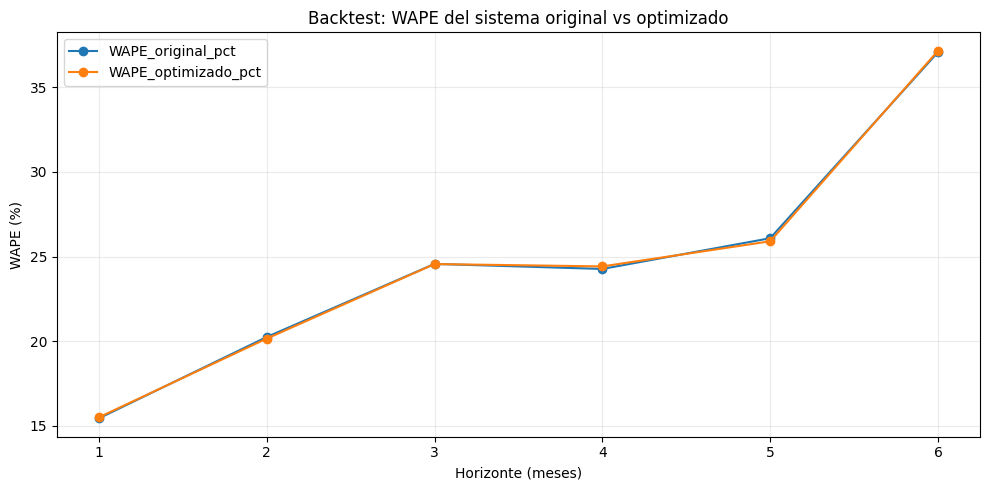


Guardado: C:\Users\Home\Documents\Datos Ebsa\Serie_tiempo_consumo\modelacion_consumo_segmentada_comparativa\comparacion_backtest_original_vs_optimizado.csv


In [47]:
# ============================================================
# 27. COMPARAR BACKTEST ORIGINAL VS OPTIMIZADO
# ============================================================
# Lee los CSV que ya generó la sección "Backtest del sistema ganador"
# del notebook de comparación (sistema SIN optimizar) y los compara
# contra lo que se acaba de calcular para el sistema optimizado.
# Esta es la respuesta real a si la búsqueda de hiperparámetros sirvió
# en el juez independiente, no solo en validación.
# ============================================================

for ruta in [RUTA_METRICAS_PERFIL, RUTA_METRICAS_BACKTEST]:
    if not ruta.exists():
        raise FileNotFoundError(
            f"No existe:\n{ruta}\n"
            "Corre primero la sección \"Backtest del sistema ganador\" "
            "del notebook de comparación (sistema original)."
        )

metricas_perfil_backtest_original = pd.read_csv(RUTA_METRICAS_PERFIL)
metricas_globales_backtest_original = pd.read_csv(RUTA_METRICAS_BACKTEST)

RUTA_COMPARACION_BACKTEST = (
    SALIDA_DIR / "comparacion_backtest_original_vs_optimizado.csv"
)

comparacion_perfil = (
    metricas_perfil_backtest_original[["perfil", "horizonte", "WAPE_final_pct"]]
    .rename(columns={"WAPE_final_pct": "WAPE_original_pct"})
    .merge(
        metricas_perfil_backtest_optimizado[["perfil", "horizonte", "WAPE_final_pct"]]
        .rename(columns={"WAPE_final_pct": "WAPE_optimizado_pct"}),
        on=["perfil", "horizonte"],
        how="outer",
    )
)

comparacion_perfil["mejora_pct_puntos"] = (
    comparacion_perfil["WAPE_original_pct"] - comparacion_perfil["WAPE_optimizado_pct"]
)

print("COMPARACIÓN POR PERFIL x HORIZONTE (backtest 2025-07-01)")
display(comparacion_perfil.sort_values(["perfil", "horizonte"]))

comparacion_global = (
    metricas_globales_backtest_original[["horizonte", "WAPE_final_pct"]]
    .rename(columns={"WAPE_final_pct": "WAPE_original_pct"})
    .merge(
        metricas_globales_backtest_optimizado[["horizonte", "WAPE_final_pct"]]
        .rename(columns={"WAPE_final_pct": "WAPE_optimizado_pct"}),
        on="horizonte",
        how="outer",
    )
)

comparacion_global["mejora_pct_puntos"] = (
    comparacion_global["WAPE_original_pct"] - comparacion_global["WAPE_optimizado_pct"]
)

print("\nCOMPARACIÓN GLOBAL POR HORIZONTE (backtest 2025-07-01)")
display(comparacion_global)

comparacion_perfil.to_csv(RUTA_COMPARACION_BACKTEST, index=False, encoding="utf-8-sig")

ax = (
    comparacion_global
    .set_index("horizonte")[["WAPE_original_pct", "WAPE_optimizado_pct"]]
    .plot(marker="o", figsize=(10, 5))
)
ax.set_title("Backtest: WAPE del sistema original vs optimizado")
ax.set_xlabel("Horizonte (meses)")
ax.set_ylabel("WAPE (%)")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

print("\nGuardado:", RUTA_COMPARACION_BACKTEST)


# Etapa 2 — Reentrenamiento final con toda la historia y pronóstico real

Igual que la sección "Reentrenamiento final y pronóstico real" del notebook
de comparación: se reentrena **solo el algoritmo ya elegido**, ahora con los
hiperparámetros optimizados, usando todos los targets conocidos hasta el
último mes del archivo. Con el histórico actual el corte es enero de 2026 y
se generan predicciones de febrero a julio de 2026. Ni el algoritmo ni el
alpha se vuelven a tocar aquí — ya quedaron fijados por la búsqueda.

In [48]:
# ============================================================
# 28. ENTRENAR MODELOS GANADORES OPTIMIZADOS FINALES
# ============================================================

FECHA_CORTE_FINAL = periodo_mes(periodo_max)

modelos_finales_optimizado = {}

print("Fecha de corte final:", FECHA_CORTE_FINAL.strftime("%Y-%m"))

for perfil in PERFILES_MODELADOS:

    for h in HORIZONTES:

        config = mapa_seleccion_optimizado[(perfil, h)]
        algoritmo = config["modelo"]
        clave = config["clave_hparams"]

        print("\n" + "=" * 75)
        print(f"FINAL OPTIMIZADO | {perfil} | h={h} | {algoritmo}")
        print("=" * 75)

        inicio = time.time()

        X_train, y_train, _ = construir_train_perfil_h(
            perfil=perfil,
            horizonte=h,
            max_target_train=FECHA_CORTE_FINAL,
            seed=SEED + 700 + h,
        )

        trial_fijo = FixedTrial(mejores_hparams[clave])

        bundle = entrenar_modelo_algoritmo_optuna(
            perfil, algoritmo, X_train, y_train, trial_fijo,
        )

        modelos_finales_optimizado[(perfil, h)] = bundle

        print(
            "Train:", X_train.shape,
            "| tiempo:", f"{(time.time() - inicio) / 60:.2f} min"
        )

        del X_train, y_train
        gc.collect()


Fecha de corte final: 2026-01

FINAL OPTIMIZADO | P0_INTERMITENTE | h=1 | LightGBM
P0_INTERMITENTE | h=1 | 1/36 | origen=2023-01 | muestra=40,000
P0_INTERMITENTE | h=1 | 6/36 | origen=2023-06 | muestra=40,000
P0_INTERMITENTE | h=1 | 12/36 | origen=2023-12 | muestra=40,000
P0_INTERMITENTE | h=1 | 18/36 | origen=2024-06 | muestra=40,000
P0_INTERMITENTE | h=1 | 24/36 | origen=2024-12 | muestra=40,000
P0_INTERMITENTE | h=1 | 30/36 | origen=2025-06 | muestra=40,000
P0_INTERMITENTE | h=1 | 36/36 | origen=2025-12 | muestra=40,000
Train: (1440000, 31) | tiempo: 1.10 min

FINAL OPTIMIZADO | P0_INTERMITENTE | h=2 | LightGBM
P0_INTERMITENTE | h=2 | 1/35 | origen=2023-01 | muestra=40,000
P0_INTERMITENTE | h=2 | 6/35 | origen=2023-06 | muestra=40,000
P0_INTERMITENTE | h=2 | 12/35 | origen=2023-12 | muestra=40,000
P0_INTERMITENTE | h=2 | 18/35 | origen=2024-06 | muestra=40,000
P0_INTERMITENTE | h=2 | 24/35 | origen=2024-12 | muestra=40,000
P0_INTERMITENTE | h=2 | 30/35 | origen=2025-06 | muestra=40,

In [49]:
# ============================================================
# 29. GUARDAR BUNDLE DE MODELOS GANADORES OPTIMIZADOS
# ============================================================

RUTA_MODELOS_OPT = SALIDA_DIR / "modelos_ganadores_optimizados_final.joblib"

joblib.dump(
    {
        "modelos": modelos_finales_optimizado,
        "seleccion_modelos_optimizada": seleccion_modelos_optimizada,
        "mapa_seleccion_optimizado": mapa_seleccion_optimizado,
        "hiperparametros": mejores_hparams,
        "features": FEATURES,
        "config_perfiles": {
            "MIN_MESES_VALIDOS_12": MIN_MESES_VALIDOS_12,
            "UMBRAL_MUY_BAJO_KWH": UMBRAL_MUY_BAJO_KWH,
            "UMBRAL_ALTO_KWH": UMBRAL_ALTO_KWH,
            "UMBRAL_GRANDE_KWH": UMBRAL_GRANDE_KWH,
            "PCT_CEROS_INTERMITENTE": PCT_CEROS_INTERMITENTE,
        },
        "fecha_corte": FECHA_CORTE_FINAL,
        "horizontes": HORIZONTES,
        "modelos_candidatos": MODELOS_CANDIDATOS,
    },
    RUTA_MODELOS_OPT,
)

print("Bundle guardado:", RUTA_MODELOS_OPT)


Bundle guardado: C:\Users\Home\Documents\Datos Ebsa\Serie_tiempo_consumo\modelacion_consumo_segmentada_comparativa\modelos_ganadores_optimizados_final.joblib


In [50]:
# ============================================================
# 30. PRONÓSTICO FINAL OPTIMIZADO t+1 A t+6
# ============================================================

perfiles_corte_final = calcular_perfiles(FECHA_CORTE_FINAL)

partes_pred_final_opt = []

for h in HORIZONTES:

    fecha_target = sumar_meses(FECHA_CORTE_FINAL, h)

    for perfil in PERFILES:

        indices = (
            perfiles_corte_final.loc[
                perfiles_corte_final["perfil"].eq(perfil), "indice",
            ]
            .to_numpy(dtype="int64")
        )

        if len(indices) == 0:
            continue

        actual = valores_mes(FECHA_CORTE_FINAL, indices)

        mask_activo = np.isfinite(actual)
        indices = indices[mask_activo]
        actual = actual[mask_activo]

        if len(indices) == 0:
            continue

        baseline = baseline_hibrido(FECHA_CORTE_FINAL, h, indices)

        if perfil == "P4_INSUFICIENTE":
            algoritmo = "Baseline"
            alpha_ml = 0.0
            pred_ml = baseline.copy()
            pred_final = baseline.copy()

        else:
            config = mapa_seleccion_optimizado[(perfil, h)]
            algoritmo = config["modelo"]
            alpha_ml = config["alpha_ml"]

            X, _ = crear_features(FECHA_CORTE_FINAL, h, indices)

            pred_ml = predecir_bundle(
                modelos_finales_optimizado[(perfil, h)], X,
            )

            pred_final = alpha_ml * pred_ml + (1 - alpha_ml) * baseline
            pred_final = np.maximum(pred_final, 0).astype("float32")

            del X

        regimen_actual = valores_regimen_mes(FECHA_CORTE_FINAL, indices)

        regimen = np.where(
            regimen_actual == 1, "reconstruido",
            np.where(regimen_actual == 0, "observado", "sin_dato"),
        )

        temp = pd.DataFrame({
            "NIU": nius[indices],
            "fecha_corte": FECHA_CORTE_FINAL,
            "horizonte": h,
            "fecha_target": fecha_target,
            "perfil": perfil,
            "regimen_actual": regimen,
            "modelo_seleccionado": algoritmo,
            "alpha_ml": alpha_ml,
            "consumo_actual_kwh": actual,
            "pred_ml_kwh": pred_ml,
            "baseline_kwh": baseline,
            "pred_final_kwh": pred_final,
        })

        partes_pred_final_opt.append(temp)
        del temp
        gc.collect()

pred_final_optimizado = pd.concat(partes_pred_final_opt, ignore_index=True)

display(pred_final_optimizado.head(20))
print("Filas pronóstico optimizado:", f"{len(pred_final_optimizado):,}")


,NIU,fecha_corte,horizonte,fecha_target,perfil,regimen_actual,modelo_seleccionado,alpha_ml,consumo_actual_kwh,pred_ml_kwh,baseline_kwh,pred_final_kwh
0,100001726,2026-01-01,1,2026-02-01,P0_INTERMITENTE,reconstruido,LightGBM,1.0,0.000000,0.025685,0.000000,0.025685
1,100005854,2026-01-01,1,2026-02-01,P0_INTERMITENTE,reconstruido,LightGBM,1.0,4.691489,3.744313,3.862069,3.744313
2,100008205,2026-01-01,1,2026-02-01,P0_INTERMITENTE,reconstruido,LightGBM,1.0,1.787234,1.149671,0.923077,1.149671
3,100010818,2026-01-01,1,2026-02-01,P0_INTERMITENTE,reconstruido,LightGBM,1.0,0.000000,0.007893,0.000000,0.007893
4,100012482,2026-01-01,1,2026-02-01,P0_INTERMITENTE,reconstruido,LightGBM,1.0,0.670213,0.621415,6.769231,0.621415
5,1000127971,2026-01-01,1,2026-02-01,P0_INTERMITENTE,reconstruido,LightGBM,1.0,0.170732,0.014987,0.608696,0.014987
6,100013269,2026-01-01,1,2026-02-01,P0_INTERMITENTE,reconstruido,LightGBM,1.0,0.000000,0.038493,0.000000,0.038493
7,100016500,2026-01-01,1,2026-02-01,P0_INTERMITENTE,reconstruido,LightGBM,1.0,0.755556,0.645194,3.218391,0.645194
8,1000201208,2026-01-01,1,2026-02-01,P0_INTERMITENTE,observado,LightGBM,1.0,0.000000,0.776153,3.000000,0.776153
9,1000211177,2026-01-01,1,2026-02-01,P0_INTERMITENTE,reconstruido,LightGBM,1.0,0.000000,0.017316,0.000000,0.017316


Filas pronóstico optimizado: 3,464,160


In [51]:
# ============================================================
# 31. FORMATO ANCHO Y GUARDAR SALIDAS 3 Y 6 MESES (OPTIMIZADO)
# ============================================================

RUTA_PRED_3M_OPT = SALIDA_DIR / "predicciones_segmentadas_optimizadas_3_meses.parquet"
RUTA_PRED_6M_OPT = SALIDA_DIR / "predicciones_segmentadas_optimizadas_6_meses.parquet"

claves = ["NIU", "fecha_corte", "perfil", "regimen_actual"]

pred_wide_opt = (
    pred_final_optimizado[claves]
    .drop_duplicates()
    .copy()
)

for h in HORIZONTES:

    temp = (
        pred_final_optimizado[pred_final_optimizado["horizonte"].eq(h)][
            claves + [
                "fecha_target", "modelo_seleccionado", "alpha_ml", "pred_final_kwh",
            ]
        ]
        .rename(columns={
            "fecha_target": f"fecha_pred_{h}m",
            "modelo_seleccionado": f"modelo_{h}m",
            "alpha_ml": f"alpha_ml_{h}m",
            "pred_final_kwh": f"pred_{h}m_kwh",
        })
    )

    pred_wide_opt = pred_wide_opt.merge(
        temp, on=claves, how="left", validate="one_to_one",
    )

pred_wide_opt["promedio_pred_3m_kwh"] = pred_wide_opt[
    ["pred_1m_kwh", "pred_2m_kwh", "pred_3m_kwh"]
].mean(axis=1)

pred_wide_opt["promedio_pred_6m_kwh"] = pred_wide_opt[
    ["pred_1m_kwh", "pred_2m_kwh", "pred_3m_kwh",
     "pred_4m_kwh", "pred_5m_kwh", "pred_6m_kwh"]
].mean(axis=1)

cols_base = ["NIU", "fecha_corte", "perfil", "regimen_actual"]

cols_3m = cols_base + [
    "fecha_pred_1m", "modelo_1m", "alpha_ml_1m", "pred_1m_kwh",
    "fecha_pred_2m", "modelo_2m", "alpha_ml_2m", "pred_2m_kwh",
    "fecha_pred_3m", "modelo_3m", "alpha_ml_3m", "pred_3m_kwh",
    "promedio_pred_3m_kwh",
]

cols_6m = cols_base + [
    "fecha_pred_1m", "modelo_1m", "alpha_ml_1m", "pred_1m_kwh",
    "fecha_pred_2m", "modelo_2m", "alpha_ml_2m", "pred_2m_kwh",
    "fecha_pred_3m", "modelo_3m", "alpha_ml_3m", "pred_3m_kwh",
    "fecha_pred_4m", "modelo_4m", "alpha_ml_4m", "pred_4m_kwh",
    "fecha_pred_5m", "modelo_5m", "alpha_ml_5m", "pred_5m_kwh",
    "fecha_pred_6m", "modelo_6m", "alpha_ml_6m", "pred_6m_kwh",
    "promedio_pred_3m_kwh", "promedio_pred_6m_kwh",
]

pred_3m_opt = pred_wide_opt[cols_3m].copy()
pred_6m_opt = pred_wide_opt[cols_6m].copy()

pred_3m_opt.to_parquet(RUTA_PRED_3M_OPT, index=False, engine="pyarrow")
pred_6m_opt.to_parquet(RUTA_PRED_6M_OPT, index=False, engine="pyarrow")

print("BACKTEST Y REENTRENAMIENTO FINAL OPTIMIZADO — TERMINADO")
print("=" * 75)

print("\nBacktest optimizado:")
print(" •", RUTA_METRICAS_PERFIL_OPT)
print(" •", RUTA_METRICAS_BACKTEST_OPT)
print(" •", RUTA_METRICAS_REGIMEN_OPT)
print(" •", RUTA_REAL_VS_PRED_OPT)
print(" •", RUTA_COMPARACION_BACKTEST, "(original vs optimizado)")

print("\nModelos finales optimizados:")
print(" •", RUTA_MODELOS_OPT)

print("\nPredicciones optimizadas:")
print(" • 3 meses:", RUTA_PRED_3M_OPT)
print(" • 6 meses:", RUTA_PRED_6M_OPT)


BACKTEST Y REENTRENAMIENTO FINAL OPTIMIZADO — TERMINADO

Backtest optimizado:
 • C:\Users\Home\Documents\Datos Ebsa\Serie_tiempo_consumo\modelacion_consumo_segmentada_comparativa\metricas_sistema_por_perfil_horizonte_optimizado.csv
 • C:\Users\Home\Documents\Datos Ebsa\Serie_tiempo_consumo\modelacion_consumo_segmentada_comparativa\metricas_sistema_ganador_backtest_optimizado.csv
 • C:\Users\Home\Documents\Datos Ebsa\Serie_tiempo_consumo\modelacion_consumo_segmentada_comparativa\metricas_sistema_por_regimen_horizonte_optimizado.csv
 • C:\Users\Home\Documents\Datos Ebsa\Serie_tiempo_consumo\modelacion_consumo_segmentada_comparativa\real_vs_pronosticado_sistema_optimizado_backtest.parquet
 • C:\Users\Home\Documents\Datos Ebsa\Serie_tiempo_consumo\modelacion_consumo_segmentada_comparativa\comparacion_backtest_original_vs_optimizado.csv (original vs optimizado)

Modelos finales optimizados:
 • C:\Users\Home\Documents\Datos Ebsa\Serie_tiempo_consumo\modelacion_consumo_segmentada_comparativa\